<a href="https://colab.research.google.com/github/Rona-w/Data-Projects/blob/main/questionnaire_data_recommender_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/My Drive/Colab Notebooks/COMP-1884-Group Project/Attention_Based_Questionnaire_Responses.csv')

In [ ]:
data

,Age,Gender,No of Siblings,Family Type,Father education level,Mother education level,Hosteler/Day scholar,"1. How 3 do you have trouble wrapping up the final details of a project, once the challenging parts have been done?",2. How 3 do you have difficulty getting things in order when you have to do a task that requires organization?,3. How 3 do you have problems remembering appointments or obligations?,...,13. How 3 do you feel restless or fidgety?,14. How 3 do you have difficulty unwinding and relaxing when you have time to yourself?,15. How 3 do you find yourself talking too much when you are in social situations?,"16. When you’re in a conversation, how 3 do you find yourself finishing the sentences of the people you are talking to, before they can finish them themselves?",17. How 3 do you have difficulty waiting your turn in situations when turn taking is required?,18. How 3 do you interrupt others when they are busy?,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,18,2,1,1,4,4,1,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00
1,19,2,2,1,3,4,2,2,2,2,...,2,1,2,2,3,1,2.33,1.67,1.83,1.94
2,18,1,1,4,3,3,2,0,0,0,...,4,4,2,0,0,0,0.00,1.67,1.67,1.11
3,19,1,1,1,3,3,1,2,1,1,...,2,1,0,0,1,0,1.50,1.50,0.67,1.22
4,18,2,0,2,1,1,1,1,2,2,...,2,2,2,2,2,2,1.83,2.00,2.00,1.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,19,2,1,1,4,3,1,1,1,1,...,1,1,1,1,1,1,1.00,1.17,1.00,1.06
356,19,1,0,1,4,4,1,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00
357,20,2,4,2,1,1,1,1,1,1,...,1,1,1,2,0,1,1.33,1.00,1.00,1.11
358,18,1,0,2,3,3,1,3,3,1,...,1,3,0,3,2,0,2.67,2.17,1.50,2.11


In [ ]:
df = data.copy()

In [ ]:
df.dtypes

,0
Age,int64
Gender,int64
No of Siblings,int64
Family Type,int64
Father education level,int64
Mother education level,int64
Hosteler/Day scholar,int64
"1. How 3 do you have trouble wrapping up the final details of a project, once the challenging parts have been done?",int64
2. How 3 do you have difficulty getting things in order when you have to do a task that requires organization?,int64
3. How 3 do you have problems remembering appointments or obligations?,int64


In [ ]:
df.columns

Index(['Age', 'Gender', 'No of Siblings ', 'Family Type',
       'Father education level', 'Mother education level',
       'Hosteler/Day scholar',
       '1. How 3 do you have trouble wrapping up the final details of a project, once the challenging parts have been done?  ',
       '2. How 3 do you have difficulty getting things in order when you have to do a task that requires organization? ',
       '3. How 3 do you have problems remembering appointments or obligations? ',
       '4. When you have a task that required a lot of thought, how 3 do you avoid or delay getting started?',
       '5. How 3 do you fidget or squirm with your hands or feet when you have to sit down for a long time? ',
       '6. How 3 do you feel overly active and compelled to do things, like you were driven by a motor? ',
       '7. How 3 do you make careless mistakes when you have to work on a boring or difficult project?',
       '8. How 3 do you have difficulty keeping your attention when you are doing bori

In [ ]:
df.shape

(360, 29)

#Drop under 18 data

In [ ]:
df["Age"].min()

17

In [ ]:
df.set_index("Age", inplace=True)

In [ ]:
df.drop(17, axis=0, inplace=True)

In [ ]:
df.shape

(338, 28)

In [ ]:
df = df.reset_index()

In [ ]:
df["Age"].min()

18

In [ ]:
df

,Age,Gender,No of Siblings,Family Type,Father education level,Mother education level,Hosteler/Day scholar,"1. How 3 do you have trouble wrapping up the final details of a project, once the challenging parts have been done?",2. How 3 do you have difficulty getting things in order when you have to do a task that requires organization?,3. How 3 do you have problems remembering appointments or obligations?,...,13. How 3 do you feel restless or fidgety?,14. How 3 do you have difficulty unwinding and relaxing when you have time to yourself?,15. How 3 do you find yourself talking too much when you are in social situations?,"16. When you’re in a conversation, how 3 do you find yourself finishing the sentences of the people you are talking to, before they can finish them themselves?",17. How 3 do you have difficulty waiting your turn in situations when turn taking is required?,18. How 3 do you interrupt others when they are busy?,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,18,2,1,1,4,4,1,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00
1,19,2,2,1,3,4,2,2,2,2,...,2,1,2,2,3,1,2.33,1.67,1.83,1.94
2,18,1,1,4,3,3,2,0,0,0,...,4,4,2,0,0,0,0.00,1.67,1.67,1.11
3,19,1,1,1,3,3,1,2,1,1,...,2,1,0,0,1,0,1.50,1.50,0.67,1.22
4,18,2,0,2,1,1,1,1,2,2,...,2,2,2,2,2,2,1.83,2.00,2.00,1.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,19,2,1,1,4,3,1,1,1,1,...,1,1,1,1,1,1,1.00,1.17,1.00,1.06
334,19,1,0,1,4,4,1,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00
335,20,2,4,2,1,1,1,1,1,1,...,1,1,1,2,0,1,1.33,1.00,1.00,1.11
336,18,1,0,2,3,3,1,3,3,1,...,1,3,0,3,2,0,2.67,2.17,1.50,2.11


#Exploratory Data Analysis

In [ ]:
df.describe()

,Age,Gender,No of Siblings,Family Type,Father education level,Mother education level,Hosteler/Day scholar,"1. How 3 do you have trouble wrapping up the final details of a project, once the challenging parts have been done?",2. How 3 do you have difficulty getting things in order when you have to do a task that requires organization?,3. How 3 do you have problems remembering appointments or obligations?,...,13. How 3 do you feel restless or fidgety?,14. How 3 do you have difficulty unwinding and relaxing when you have time to yourself?,15. How 3 do you find yourself talking too much when you are in social situations?,"16. When you’re in a conversation, how 3 do you find yourself finishing the sentences of the people you are talking to, before they can finish them themselves?",17. How 3 do you have difficulty waiting your turn in situations when turn taking is required?,18. How 3 do you interrupt others when they are busy?,1_6 Score,7_12 Score,13_18 Score,1_18 score
count,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,...,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000
mean,18.976331,1.378698,1.473373,1.724852,2.636095,2.443787,1.408284,1.556213,1.544379,1.393491,...,1.946746,1.428994,1.544379,1.520710,1.553254,0.964497,1.611095,1.670237,1.493195,1.591538
std,1.165542,0.485782,1.092543,0.979631,0.962563,1.072217,0.492245,0.976629,0.974199,1.060017,...,1.035055,1.051770,1.116154,1.022528,1.075132,1.030073,0.655401,0.719334,0.632109,0.576118
min,18.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.170000,1.170000,1.000000,1.220000
50%,19.000000,1.000000,1.000000,1.000000,3.000000,3.000000,1.000000,2.000000,2.000000,1.000000,...,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.670000,1.670000,1.500000,1.610000
75%,19.750000,2.000000,2.000000,2.000000,3.000000,3.000000,2.000000,2.000000,2.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.940000
max,23.000000,2.000000,7.000000,5.000000,4.000000,4.000000,2.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


Changing names of features to make EDA easier.

In [ ]:
df.iloc[:, 7:25]

,"1. How 3 do you have trouble wrapping up the final details of a project, once the challenging parts have been done?",2. How 3 do you have difficulty getting things in order when you have to do a task that requires organization?,3. How 3 do you have problems remembering appointments or obligations?,"4. When you have a task that required a lot of thought, how 3 do you avoid or delay getting started?",5. How 3 do you fidget or squirm with your hands or feet when you have to sit down for a long time?,"6. How 3 do you feel overly active and compelled to do things, like you were driven by a motor?",7. How 3 do you make careless mistakes when you have to work on a boring or difficult project?,8. How 3 do you have difficulty keeping your attention when you are doing boring or repetitive work?,"9. How 3 do you have difficulty concentrating on what people say to you, even when they are speaking to you directly?",10. How 3 do you misplace or have difficulty finding things at home or at work?,11. How 3 are you distracted by activity or noise around you?,12. How 3 do you leave your seat in meetings or other situations in which you are expected to remain seated?,13. How 3 do you feel restless or fidgety?,14. How 3 do you have difficulty unwinding and relaxing when you have time to yourself?,15. How 3 do you find yourself talking too much when you are in social situations?,"16. When you’re in a conversation, how 3 do you find yourself finishing the sentences of the people you are talking to, before they can finish them themselves?",17. How 3 do you have difficulty waiting your turn in situations when turn taking is required?,18. How 3 do you interrupt others when they are busy?
0,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
1,2,2,2,3,3,2,2,3,1,1,2,1,2,1,2,2,3,1
2,0,0,0,0,0,0,0,1,1,2,2,4,4,4,2,0,0,0
3,2,1,1,2,1,2,1,3,1,1,3,0,2,1,0,0,1,0
4,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,1,1,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1
334,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
335,1,1,1,2,1,2,1,1,1,1,1,1,1,1,1,2,0,1
336,3,3,1,2,4,3,3,4,1,1,4,0,1,3,0,3,2,0


In [ ]:
df.columns[7:25]

Index(['1. How 3 do you have trouble wrapping up the final details of a project, once the challenging parts have been done?  ',
       '2. How 3 do you have difficulty getting things in order when you have to do a task that requires organization? ',
       '3. How 3 do you have problems remembering appointments or obligations? ',
       '4. When you have a task that required a lot of thought, how 3 do you avoid or delay getting started?',
       '5. How 3 do you fidget or squirm with your hands or feet when you have to sit down for a long time? ',
       '6. How 3 do you feel overly active and compelled to do things, like you were driven by a motor? ',
       '7. How 3 do you make careless mistakes when you have to work on a boring or difficult project?',
       '8. How 3 do you have difficulty keeping your attention when you are doing boring or repetitive work?',
       '9. How 3 do you have difficulty concentrating on what people say to you, even when they are speaking to you directl

In [ ]:
df1=df.copy()

Rename Questionnaire features:

Inattention (AT) 1-6

Hyperactivity (HA) 1-6

Impulsivity (IM) 1-6

(renaming based on question type, also as seen in article from original dataset)

Note: I believe the original data has a typo with the "3" in each question, it should be 4 if anything as it's the highest value.

In [ ]:
df1.rename(columns={ df1.columns[7]:"AT_1", df1.columns[8]:"AT_2", df1.columns[9]:"AT_3",
                    df1.columns[10]:"AT_4", df1.columns[11]:"AT_5", df1.columns[12]:"AT_6"}, inplace = True)


In [ ]:
df1.rename(columns={ df1.columns[13]:"HA_1", df1.columns[14]:"HA_2", df1.columns[15]:"HA_3",
                    df1.columns[16]:"HA_4", df1.columns[17]:"HA_5", df1.columns[18]:"HA_6"}, inplace = True)




In [ ]:
df1.rename(columns={ df1.columns[19]:"IM_1", df1.columns[20]:"IM_2", df1.columns[21]:"IM_3",
                    df1.columns[22]:"IM_4", df1.columns[23]:"IM_5", df1.columns[24]:"IM_6"}, inplace = True)




In [ ]:
df1.columns[7:25]

Index(['AT_1', 'AT_2', 'AT_3', 'AT_4', 'AT_5', 'AT_6', 'HA_1', 'HA_2', 'HA_3',
       'HA_4', 'HA_5', 'HA_6', 'IM_1', 'IM_2', 'IM_3', 'IM_4', 'IM_5', 'IM_6'],
      dtype='object')

In [ ]:
#df1.to_csv("attention_based_questionnaire_responses_cleaned.csv", index=False)"""

In [ ]:
df1.index[300:]

RangeIndex(start=300, stop=338, step=1)

In [ ]:
df1


,Age,Gender,No of Siblings,Family Type,Father education level,Mother education level,Hosteler/Day scholar,AT_1,AT_2,AT_3,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,18,2,1,1,4,4,1,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00
1,19,2,2,1,3,4,2,2,2,2,...,2,1,2,2,3,1,2.33,1.67,1.83,1.94
2,18,1,1,4,3,3,2,0,0,0,...,4,4,2,0,0,0,0.00,1.67,1.67,1.11
3,19,1,1,1,3,3,1,2,1,1,...,2,1,0,0,1,0,1.50,1.50,0.67,1.22
4,18,2,0,2,1,1,1,1,2,2,...,2,2,2,2,2,2,1.83,2.00,2.00,1.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,19,2,1,1,4,3,1,1,1,1,...,1,1,1,1,1,1,1.00,1.17,1.00,1.06
334,19,1,0,1,4,4,1,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00
335,20,2,4,2,1,1,1,1,1,1,...,1,1,1,2,0,1,1.33,1.00,1.00,1.11
336,18,1,0,2,3,3,1,3,3,1,...,1,3,0,3,2,0,2.67,2.17,1.50,2.11


In [ ]:
df1.iloc[3]

,3
Age,19.00
Gender,1.00
No of Siblings,1.00
Family Type,1.00
Father education level,3.00
Mother education level,3.00
Hosteler/Day scholar,1.00
AT_1,2.00
AT_2,1.00
AT_3,1.00


In [ ]:
select = ['Gender', 'AT_1', 'AT_2', 'AT_3', 'AT_4', 'AT_5', 'AT_6',
       'HA_1', 'HA_2', 'HA_3', 'HA_4', 'HA_5', 'HA_6', 'IM_1', 'IM_2', 'IM_3',
       'IM_4', 'IM_5', 'IM_6', '1_6 Score', '7_12 Score', '13_18 Score',
       '1_18 score']

<Axes: >

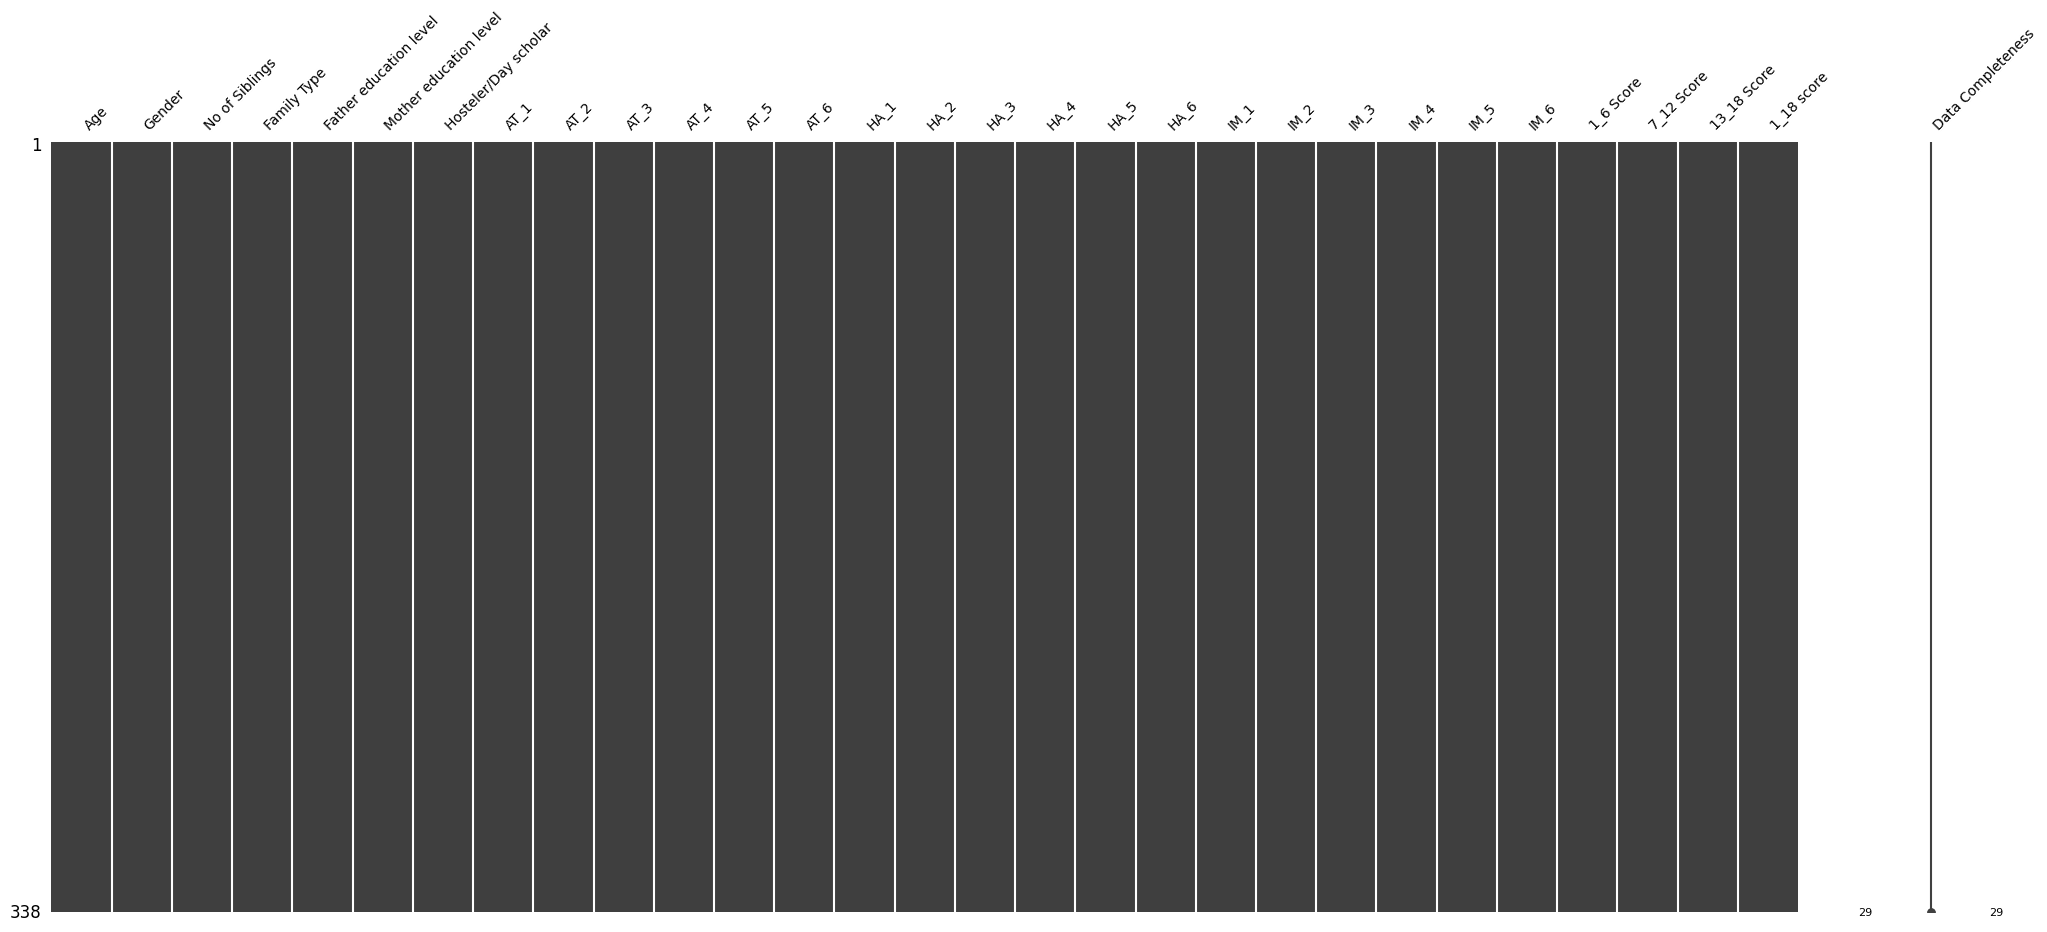

In [ ]:
msno.matrix(df1, fontsize=10, labels=True)

No missing values.

<Axes: >

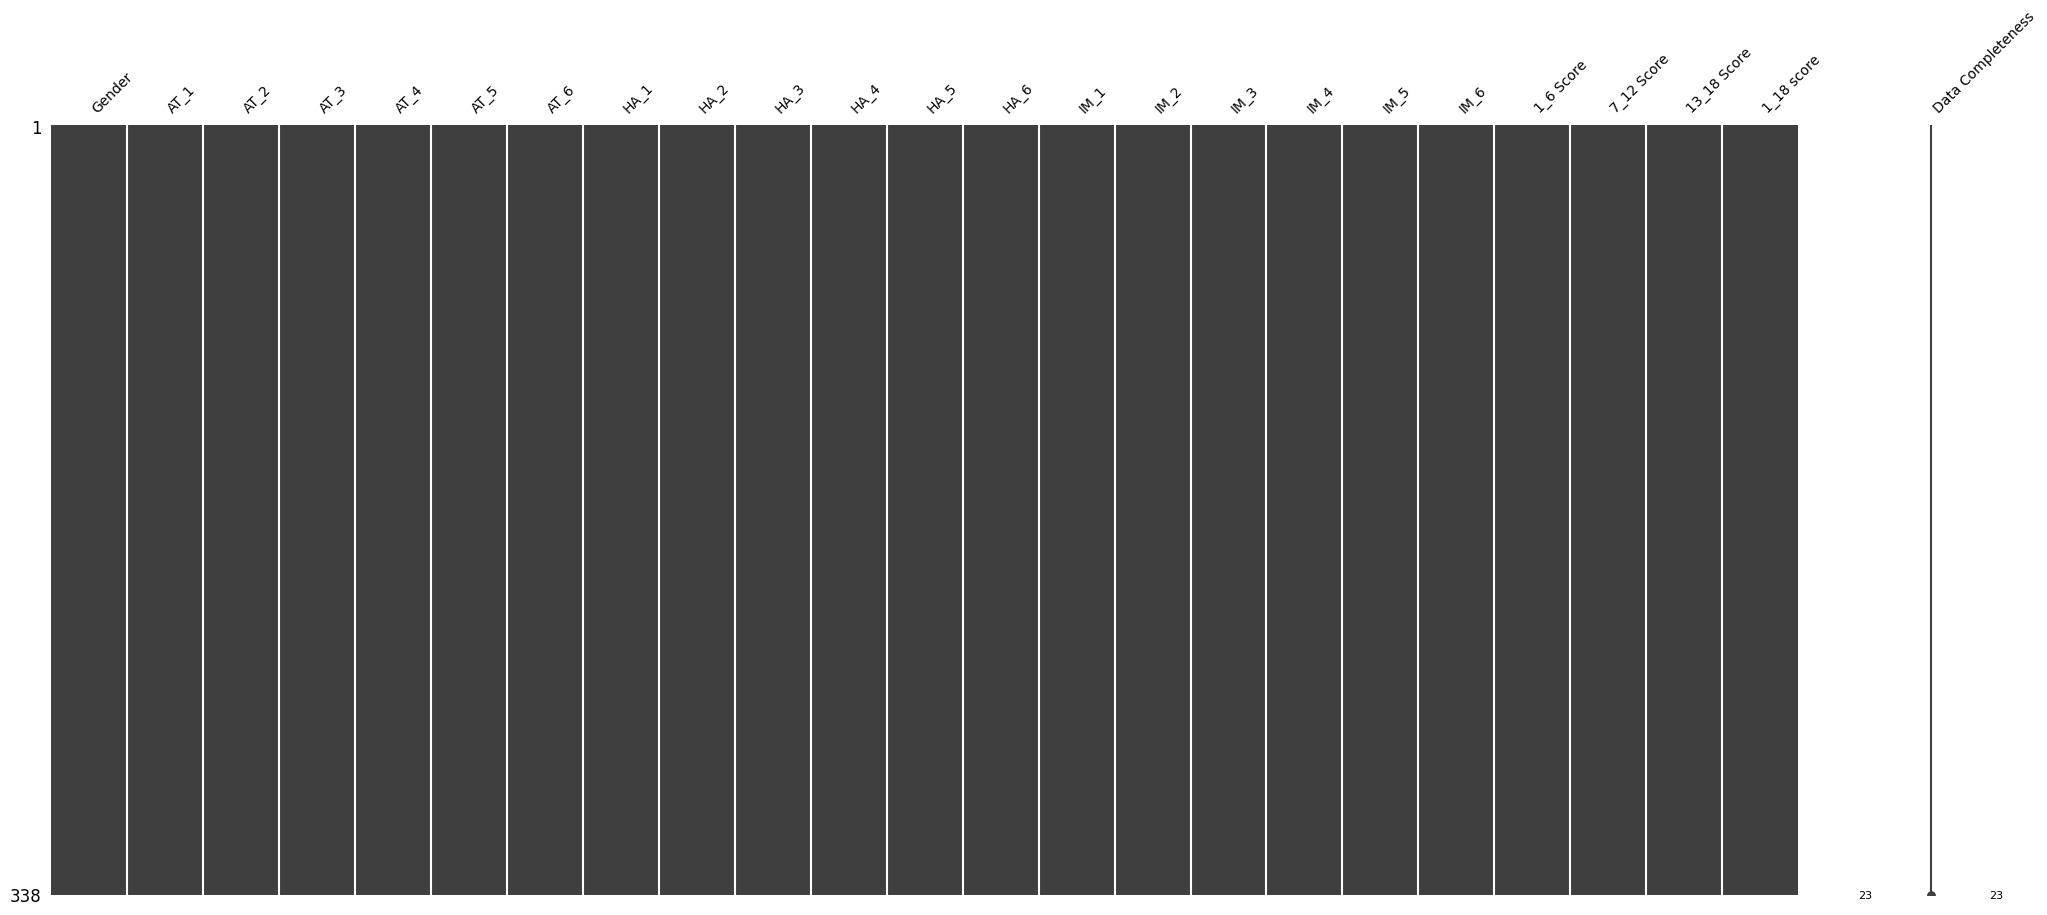

In [ ]:
msno.matrix(df1[select], fontsize=10, labels=True)

In [ ]:
label = ['Age', 'Gender', 'No of Siblings ', 'Family Type',
       'Father education level', 'Mother education level',
       'Hosteler/Day scholar', 'AT_1', 'AT_2', 'AT_3', 'AT_4', 'AT_5', 'AT_6',
       'HA_1', 'HA_2', 'HA_3', 'HA_4', 'HA_5', 'HA_6', 'IM_1', 'IM_2', 'IM_3',
       'IM_4', 'IM_5', 'IM_6', '1_6 Score', '7_12 Score', '13_18 Score',
       '1_18 score']

In [ ]:
df1.columns

Index(['Age', 'Gender', 'No of Siblings ', 'Family Type',
       'Father education level', 'Mother education level',
       'Hosteler/Day scholar', 'AT_1', 'AT_2', 'AT_3', 'AT_4', 'AT_5', 'AT_6',
       'HA_1', 'HA_2', 'HA_3', 'HA_4', 'HA_5', 'HA_6', 'IM_1', 'IM_2', 'IM_3',
       'IM_4', 'IM_5', 'IM_6', '1_6 Score', '7_12 Score', '13_18 Score',
       '1_18 score'],
      dtype='object')

/tmp/ipython-input-956858960.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df1, labels=label)


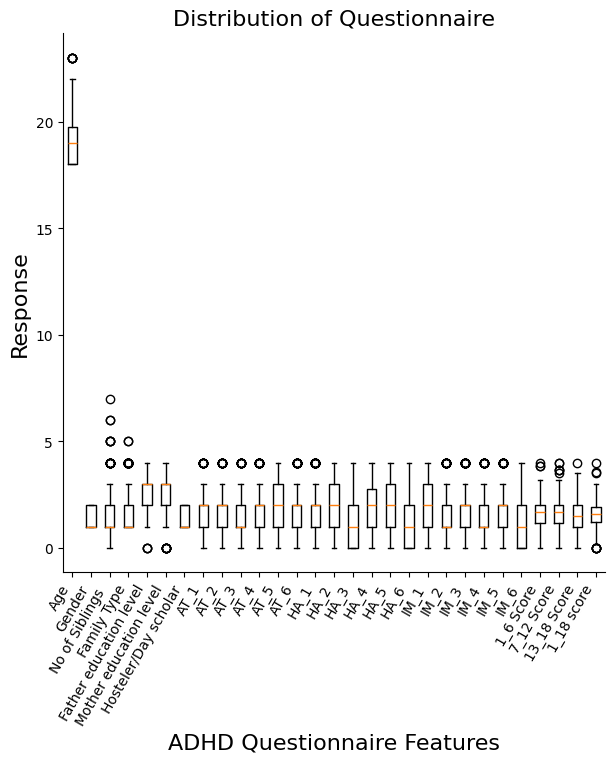

In [ ]:
plt.figure(figsize=(7, 7))
# data[selected].boxplot()
plt.boxplot(df1, labels=label)
plt.xlabel('ADHD Questionnaire Features', fontsize=16)
plt.xticks(rotation=60, ha='right')
plt.ylabel('Response', fontsize=16)
plt.title('Distribution of Questionnaire', fontsize=16)

for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
  if spine.spine_type != 'bottom' and spine.spine_type != 'left':
    spine.set_visible(False)

plt.show()

/tmp/ipython-input-944419552.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df1[select], labels=select)


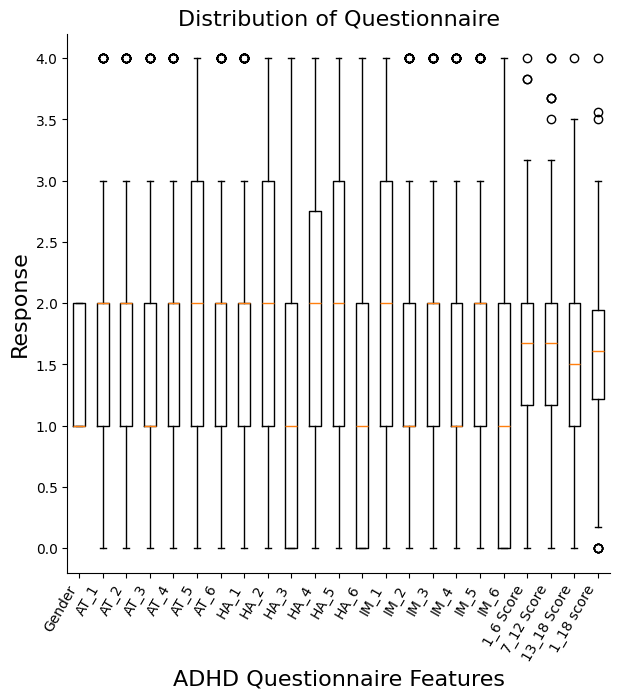

In [ ]:
plt.figure(figsize=(7, 7))
# data[selected].boxplot()
plt.boxplot(df1[select], labels=select)
plt.xlabel('ADHD Questionnaire Features', fontsize=16)
plt.xticks(rotation=60, ha='right')
plt.ylabel('Response', fontsize=16)
plt.title('Distribution of Questionnaire', fontsize=16)

for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
  if spine.spine_type != 'bottom' and spine.spine_type != 'left':
    spine.set_visible(False)

plt.show()

Feature 27 (7_12 Score) has the most outliers. Could be errors in responses. Feature 1 is age which has the largest range between all the features. The smallest range is features 2 and 7 which are gender and Hosteler/Day scholar, with a range of 1.

#Correlation Matrix

This is hard to read.

Correlation matrix in different format.

In [ ]:
matrix = df1.corr()
print("Correlation matrix is : ")
print(matrix)

Correlation matrix is : 
                             Age    Gender  No of Siblings   Family Type  \
Age                     1.000000  0.005396         0.081063    -0.070692   
Gender                  0.005396  1.000000        -0.031263    -0.036047   
No of Siblings          0.081063 -0.031263         1.000000    -0.033204   
Family Type            -0.070692 -0.036047        -0.033204     1.000000   
Father education level -0.071178  0.029064        -0.213811     0.035109   
Mother education level -0.072301 -0.033070        -0.359712     0.029019   
Hosteler/Day scholar    0.027237  0.009178         0.042345     0.018279   
AT_1                   -0.053571 -0.045003        -0.022232    -0.022555   
AT_2                    0.016608 -0.023077        -0.003068     0.020606   
AT_3                    0.091622 -0.059740         0.097471    -0.041164   
AT_4                    0.072324 -0.093422        -0.072066    -0.030496   
AT_5                   -0.066645 -0.133743        -0.063029    

In [ ]:
!pip install hvplot
import holoviews as hv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.5/175.5 kB 5.9 MB/s eta 0:00:00


In [ ]:
import hvplot.pandas

Interactive correlation matrix.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
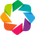

:HeatMap   [columns,index]   (value)

In [ ]:
plot = df1.corr().hvplot.heatmap(
    frame_height=500, frame_width=500,
    title='Questionnaire Correlations',
    rot=90, cmap='coolwarm'  # see http://holoviews.org/user_guide/Colormaps.html
).opts(invert_yaxis=True, clim=(-1, 1))
hv.extension('bokeh')
plot

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
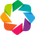

:HeatMap   [columns,index]   (value)

In [ ]:
plot = df1[select].corr().hvplot.heatmap(
    frame_height=500, frame_width=500,
    title='Questionnaire Correlations',
    rot=90, cmap='coolwarm'  # see http://holoviews.org/user_guide/Colormaps.html
).opts(invert_yaxis=True, clim=(-1, 1))
hv.extension('bokeh')
plot

In [ ]:
df["Age"].nlargest(10)

,Age
6,23
29,23
151,23
202,23
275,23
301,23
45,22
49,22
72,22
91,22


In [ ]:
df["Age"].mode()

,Age
0,18


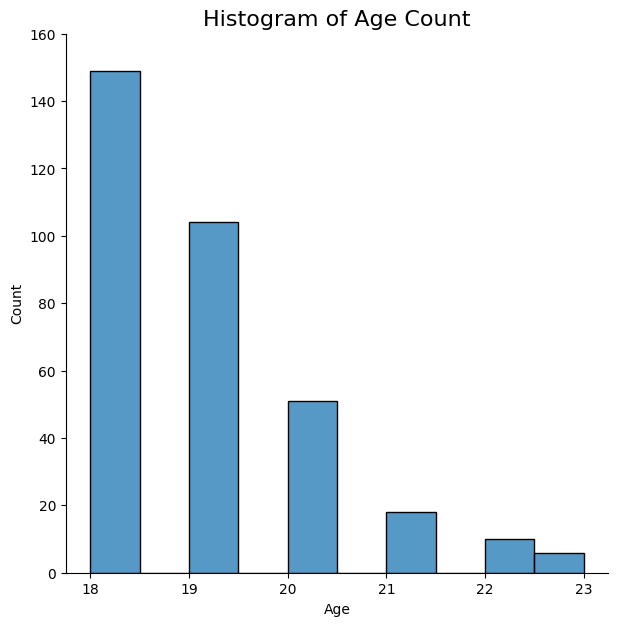

In [ ]:
age = df['Age']
plt.figure(figsize=(7, 7))
sns.histplot(age)
#reduce gap (search parameters, kde probability density (bell curve, to see the skew), what does it tell you about adhd)
plt.ylim(0,160)
plt.title('Histogram of Age Count', fontsize=16)
for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
      if spine.spine_type != 'bottom' and spine.spine_type != 'left':
        spine.set_visible(False)

In [ ]:
print (age.value_counts())

Age
18    149
19    104
20     51
21     18
22     10
23      6
Name: count, dtype: int64


1 = Female
2 = Male

https://stackoverflow.com/questions/36762199/how-to-plot-bars-from-pandas-value-counts

Gender
Female    210
Male      128
Name: count, dtype: int64


/tmp/ipython-input-4001257197.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  gendercount = pd.value_counts(df['Gender'].map({1: 'Female', 2: 'Male'}), sort=True)


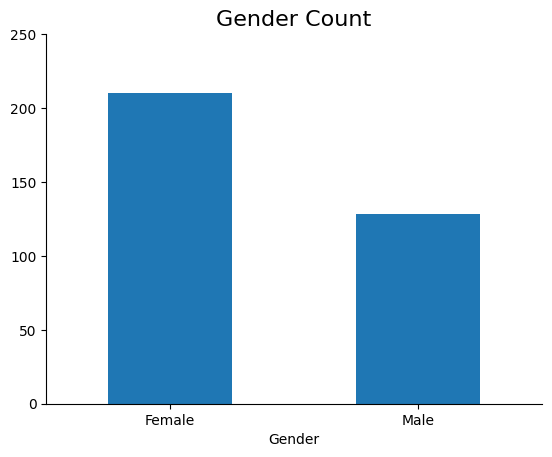

In [ ]:
gendercount = pd.value_counts(df['Gender'].map({1: 'Female', 2: 'Male'}), sort=True)
print (gendercount)
plt.ylim(0,250)
gendercount.plot.bar()
plt.title('Gender Count', fontsize=16)
plt.xticks(rotation=0)
plt.xlabel ('Gender')
for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
      if spine.spine_type != 'bottom' and spine.spine_type != 'left':
        spine.set_visible(False)

In [ ]:
df['Gender'].value_counts()

,count
Gender,
1,210
2,128


More females than males in this survey.

#Creating content

In [ ]:
cdf = df1.copy()

In [ ]:
content = {
    'Content 0': ['no content recommendation'],
    'Content 1': ['memory retention', 'timed quiz', '"algebra"'],
    'Content 2': ['quiz', 'interactive content', '"fill_in_1"'],
    'Content 3': ['simplification', 'content chunking', '"choose_1"']
}

In [ ]:
content

{'Content 0': ['no content recommendation'],
 'Content 1': ['memory retention', 'timed quiz', '"algebra"'],
 'Content 2': ['quiz', 'interactive content', '"fill_in_1"'],
 'Content 3': ['simplification', 'content chunking', '"choose_1"']}

In [ ]:
"""def assign_content(row):
    a = row['1_6 Score']
    b = row['7_12 Score']
    c = row['13_18 Score']

    if 2 <= a < 3:
        return content['Content 1']
    elif 2 <= b < 3 or 2 <= c < 3:
        return content['Content 2']
    elif a >= 3 or b >= 3 or c >= 3 or (2 <= a and b < 3) or (2 <= a and c < 3):
        return content['Content 3']
    else:
        return content['Content 0']

# Apply the function to each row
cdf['Content'] = cdf.apply(assign_content, axis=1)"""


"def assign_content(row):\n    a = row['1_6 Score']\n    b = row['7_12 Score']\n    c = row['13_18 Score']\n\n    if 2 <= a < 3:\n        return content['Content 1']\n    elif 2 <= b < 3 or 2 <= c < 3:\n        return content['Content 2']\n    elif a >= 3 or b >= 3 or c >= 3 or (2 <= a and b < 3) or (2 <= a and c < 3):\n        return content['Content 3']\n    else:\n        return content['Content 0']\n\n# Apply the function to each row\ncdf['Content'] = cdf.apply(assign_content, axis=1)"

In [ ]:
def assign_content(row):
    a = row['1_6 Score']
    b = row['7_12 Score']
    c = row['13_18 Score']

    if 2 <= a < 3 and b < 2 and c < 2:
        return 'Content 1'
    elif 2 <= b < 3 and 2 <= c < 3 and a < 2:
        return 'Content 2'
    elif a >= 3 or b >= 3 or c >= 3 or (2 <= a and b < 3) or (2 <= a and c < 3):
        return 'Content 3'
    else:
        return 'Content 0'

cdf['Content'] = cdf.apply(assign_content, axis=1)

In [ ]:
cdf['Content List'] = cdf['Content'].map(content)

In [ ]:
cdf

,Age,Gender,No of Siblings,Family Type,Father education level,Mother education level,Hosteler/Day scholar,AT_1,AT_2,AT_3,...,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content,Content List
0,18,2,1,1,4,4,1,2,2,2,...,2,2,2,2,2.00,2.00,2.00,2.00,Content 3,"[simplification, content chunking, ""choose_1""]"
1,19,2,2,1,3,4,2,2,2,2,...,2,2,3,1,2.33,1.67,1.83,1.94,Content 1,"[memory retention, timed quiz, ""algebra""]"
2,18,1,1,4,3,3,2,0,0,0,...,2,0,0,0,0.00,1.67,1.67,1.11,Content 0,[no content recommendation]
3,19,1,1,1,3,3,1,2,1,1,...,0,0,1,0,1.50,1.50,0.67,1.22,Content 0,[no content recommendation]
4,18,2,0,2,1,1,1,1,2,2,...,2,2,2,2,1.83,2.00,2.00,1.94,Content 2,"[quiz, interactive content, ""fill_in_1""]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,19,2,1,1,4,3,1,1,1,1,...,1,1,1,1,1.00,1.17,1.00,1.06,Content 0,[no content recommendation]
334,19,1,0,1,4,4,1,2,2,2,...,2,2,2,2,2.00,2.00,2.00,2.00,Content 3,"[simplification, content chunking, ""choose_1""]"
335,20,2,4,2,1,1,1,1,1,1,...,1,2,0,1,1.33,1.00,1.00,1.11,Content 0,[no content recommendation]
336,18,1,0,2,3,3,1,3,3,1,...,0,3,2,0,2.67,2.17,1.50,2.11,Content 3,"[simplification, content chunking, ""choose_1""]"


In [ ]:
content['Content 1']

['memory retention', 'timed quiz', '"algebra"']

In [ ]:
cdf['Content'].value_counts()


,count
Content,
Content 0,199
Content 3,89
Content 1,33
Content 2,17


Note: there might be a priority for content 1 as it would be assigned first if requirements are met. I need to code in a way that the highest number from each column is assigned instead of the first.

In [ ]:
pip install pysankey

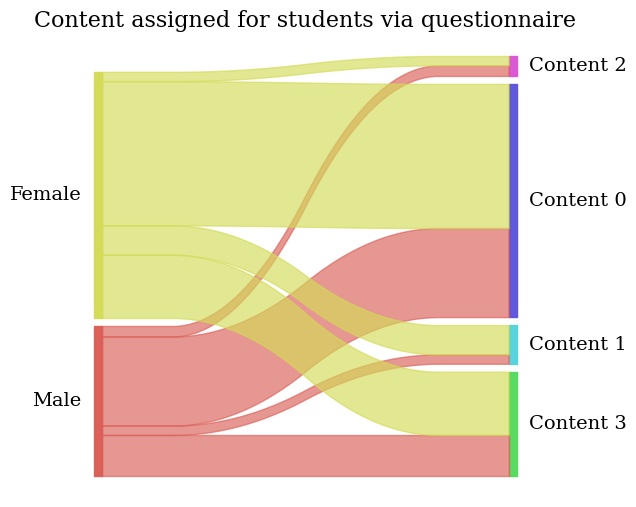

In [ ]:
from pySankey.sankey import sankey
sankey(left=cdf['Gender'].map({1: 'Female', 2: 'Male'}), right=cdf['Content'], aspect=20)
plt.title('Content assigned for students via questionnaire', fontsize=16)
plt.show()
#add a legend, what does each gender mean

Shows more females have a higher overall questionnaire score than males.

In [ ]:
sym_df = cdf[cdf['Content'] != 'Content 0'].copy()

In [ ]:
sym_df = sym_df.reset_index()

In [ ]:
sym_df.drop(['index'], axis=1, inplace=True)

In [ ]:
sym_df

,Age,Gender,No of Siblings,Family Type,Father education level,Mother education level,Hosteler/Day scholar,AT_1,AT_2,AT_3,...,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content,Content List
0,18,2,1,1,4,4,1,2,2,2,...,2,2,2,2,2.00,2.00,2.00,2.00,Content 3,"[simplification, content chunking, ""choose_1""]"
1,19,2,2,1,3,4,2,2,2,2,...,2,2,3,1,2.33,1.67,1.83,1.94,Content 1,"[memory retention, timed quiz, ""algebra""]"
2,18,2,0,2,1,1,1,1,2,2,...,2,2,2,2,1.83,2.00,2.00,1.94,Content 2,"[quiz, interactive content, ""fill_in_1""]"
3,18,2,0,2,2,1,1,2,3,2,...,3,3,2,2,2.17,2.17,2.50,2.28,Content 3,"[simplification, content chunking, ""choose_1""]"
4,23,2,5,2,3,0,2,1,2,2,...,2,3,4,4,0.83,2.17,2.17,1.72,Content 2,"[quiz, interactive content, ""fill_in_1""]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,19,1,1,2,3,2,2,3,2,3,...,0,4,2,0,2.17,1.33,1.67,1.72,Content 1,"[memory retention, timed quiz, ""algebra""]"
135,21,1,1,2,3,2,2,3,2,3,...,0,4,2,0,2.17,1.33,1.67,1.72,Content 1,"[memory retention, timed quiz, ""algebra""]"
136,18,2,1,2,1,2,2,2,2,2,...,2,2,2,2,2.00,2.00,2.00,2.00,Content 3,"[simplification, content chunking, ""choose_1""]"
137,19,1,0,1,4,4,1,2,2,2,...,2,2,2,2,2.00,2.00,2.00,2.00,Content 3,"[simplification, content chunking, ""choose_1""]"


In [ ]:
sym_df.shape

(139, 31)

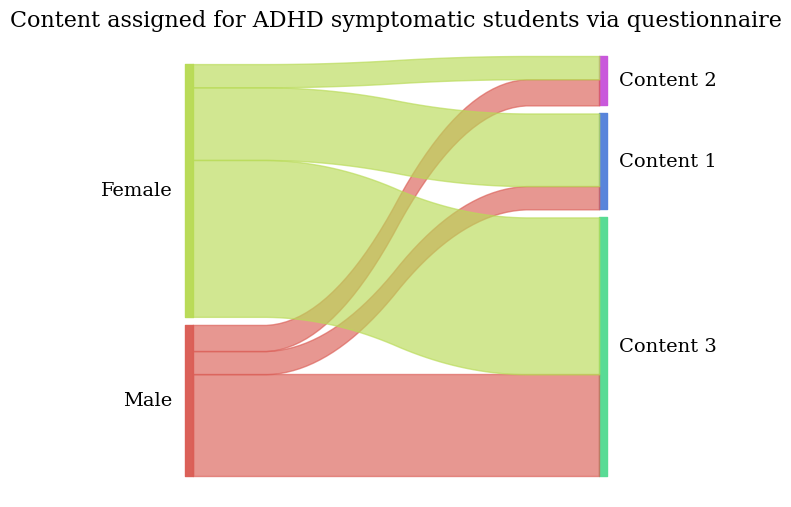

In [ ]:
from pySankey.sankey import sankey
sankey(left=sym_df['Gender'].map({1: 'Female', 2: 'Male'}), right=sym_df['Content'], aspect=20)
plt.title('Content assigned for ADHD symptomatic students via questionnaire', fontsize=16)
plt.show()

In [ ]:
sym_df['Content'].value_counts()

,count
Content,
Content 3,89
Content 1,33
Content 2,17


#Numeric features of symptomatic data - need to drop content

In [ ]:
numeric_features = sym_df.select_dtypes(include=[np.number])

numeric_features.columns

Index(['Age', 'Gender', 'No of Siblings ', 'Family Type',
       'Father education level', 'Mother education level',
       'Hosteler/Day scholar', 'AT_1', 'AT_2', 'AT_3', 'AT_4', 'AT_5', 'AT_6',
       'HA_1', 'HA_2', 'HA_3', 'HA_4', 'HA_5', 'HA_6', 'IM_1', 'IM_2', 'IM_3',
       'IM_4', 'IM_5', 'IM_6', '1_6 Score', '7_12 Score', '13_18 Score',
       '1_18 score'],
      dtype='object')

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
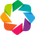

:HeatMap   [columns,index]   (value)

In [ ]:
sym_df
plot = numeric_features.corr().hvplot.heatmap(
    frame_height=500, frame_width=500,
    title='Symptomatic Questionnaire Correlations',
    rot=90, cmap='coolwarm'  # see http://holoviews.org/user_guide/Colormaps.html
).opts(invert_yaxis=True, clim=(-1, 1))
hv.extension('bokeh')
plot

There is still a very high positive correlation between the questionnaire averages in the symptomatic dataset. However, the actual questions have a weaker correlation than the mixed asymptomatic and symptomatic dataset. This could be due to less data.

Gender for Symptomatic

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
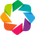

:HeatMap   [columns,index]   (value)

In [ ]:
sym_df
plot = numeric_features[select].corr().hvplot.heatmap(
    frame_height=500, frame_width=500,
    title='Symptomatic Questionnaire Correlations',
    rot=90, cmap='coolwarm'  # see http://holoviews.org/user_guide/Colormaps.html
).opts(invert_yaxis=True, clim=(-1, 1))
hv.extension('bokeh')
plot

Gender
Female    87
Male      52
Name: count, dtype: int64


/tmp/ipython-input-3782012458.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  gendercount = pd.value_counts(sym_df['Gender'].map({1: 'Female', 2: 'Male'}), sort=True)


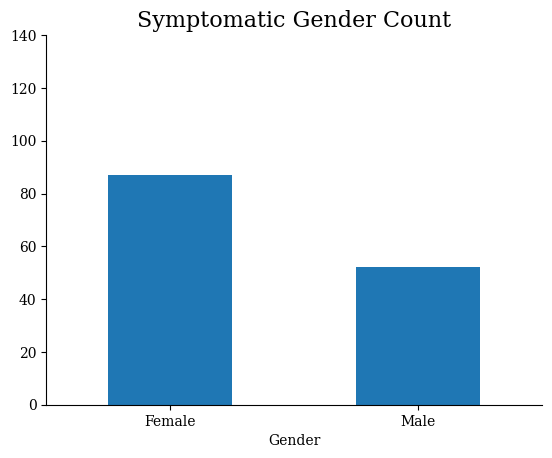

In [ ]:
gendercount = pd.value_counts(sym_df['Gender'].map({1: 'Female', 2: 'Male'}), sort=True)
print (gendercount)
plt.ylim(0,140)
gendercount.plot.bar()
plt.title('Symptomatic Gender Count', fontsize=16)
plt.xticks(rotation=0)
plt.xlabel ('Gender')
for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
      if spine.spine_type != 'bottom' and spine.spine_type != 'left':
        spine.set_visible(False)

#Creating CSV files

In [ ]:
symptomatic = sym_df.copy()

In [ ]:
symptomatic["Content List"]

,Content List
0,"[simplification, content chunking, ""choose_1""]"
1,"[memory retention, timed quiz, ""algebra""]"
2,"[quiz, interactive content, ""fill_in_1""]"
3,"[simplification, content chunking, ""choose_1""]"
4,"[quiz, interactive content, ""fill_in_1""]"
...,...
134,"[memory retention, timed quiz, ""algebra""]"
135,"[memory retention, timed quiz, ""algebra""]"
136,"[simplification, content chunking, ""choose_1""]"
137,"[simplification, content chunking, ""choose_1""]"


In [ ]:
symptomatic.drop(['Content List'], axis=1, inplace=True)

In [ ]:
symptomatic

,Age,Gender,No of Siblings,Family Type,Father education level,Mother education level,Hosteler/Day scholar,AT_1,AT_2,AT_3,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content
0,18,2,1,1,4,4,1,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,Content 3
1,19,2,2,1,3,4,2,2,2,2,...,1,2,2,3,1,2.33,1.67,1.83,1.94,Content 1
2,18,2,0,2,1,1,1,1,2,2,...,2,2,2,2,2,1.83,2.00,2.00,1.94,Content 2
3,18,2,0,2,2,1,1,2,3,2,...,2,3,3,2,2,2.17,2.17,2.50,2.28,Content 3
4,23,2,5,2,3,0,2,1,2,2,...,0,2,3,4,4,0.83,2.17,2.17,1.72,Content 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,19,1,1,2,3,2,2,3,2,3,...,2,0,4,2,0,2.17,1.33,1.67,1.72,Content 1
135,21,1,1,2,3,2,2,3,2,3,...,2,0,4,2,0,2.17,1.33,1.67,1.72,Content 1
136,18,2,1,2,1,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,Content 3
137,19,1,0,1,4,4,1,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,Content 3


In [ ]:
#symptomatic.to_csv("symptomatic_questionnaire_responses_with_content.csv", index=False)

In [ ]:
only_sym = symptomatic.copy()

In [ ]:
only_sym

,Age,Gender,No of Siblings,Family Type,Father education level,Mother education level,Hosteler/Day scholar,AT_1,AT_2,AT_3,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content
0,18,2,1,1,4,4,1,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,Content 3
1,19,2,2,1,3,4,2,2,2,2,...,1,2,2,3,1,2.33,1.67,1.83,1.94,Content 1
2,18,2,0,2,1,1,1,1,2,2,...,2,2,2,2,2,1.83,2.00,2.00,1.94,Content 2
3,18,2,0,2,2,1,1,2,3,2,...,2,3,3,2,2,2.17,2.17,2.50,2.28,Content 3
4,23,2,5,2,3,0,2,1,2,2,...,0,2,3,4,4,0.83,2.17,2.17,1.72,Content 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,19,1,1,2,3,2,2,3,2,3,...,2,0,4,2,0,2.17,1.33,1.67,1.72,Content 1
135,21,1,1,2,3,2,2,3,2,3,...,2,0,4,2,0,2.17,1.33,1.67,1.72,Content 1
136,18,2,1,2,1,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,Content 3
137,19,1,0,1,4,4,1,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,Content 3


In [ ]:
only_sym.drop(['Content'], axis=1, inplace=True)

In [ ]:
#only_sym.to_csv("symptomatic_questionnaire_responses.csv", index=False)

#Collaborative Filtering - K Nearest Neighbour Algorithm

https://towardsdatascience.com/multiclass-classification-using-k-nearest-neighbours-ca5281a9ef76/ Reference

In [ ]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
sym_df['Content'].value_counts()

,count
Content,
Content 3,89
Content 1,33
Content 2,17


In [ ]:
feature_list = sym_df.copy()

In [ ]:
feature_list

,Age,Gender,No of Siblings,Family Type,Father education level,Mother education level,Hosteler/Day scholar,AT_1,AT_2,AT_3,...,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content,Content List
0,18,2,1,1,4,4,1,2,2,2,...,2,2,2,2,2.00,2.00,2.00,2.00,Content 3,"[simplification, content chunking, ""choose_1""]"
1,19,2,2,1,3,4,2,2,2,2,...,2,2,3,1,2.33,1.67,1.83,1.94,Content 1,"[memory retention, timed quiz, ""algebra""]"
2,18,2,0,2,1,1,1,1,2,2,...,2,2,2,2,1.83,2.00,2.00,1.94,Content 2,"[quiz, interactive content, ""fill_in_1""]"
3,18,2,0,2,2,1,1,2,3,2,...,3,3,2,2,2.17,2.17,2.50,2.28,Content 3,"[simplification, content chunking, ""choose_1""]"
4,23,2,5,2,3,0,2,1,2,2,...,2,3,4,4,0.83,2.17,2.17,1.72,Content 2,"[quiz, interactive content, ""fill_in_1""]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,19,1,1,2,3,2,2,3,2,3,...,0,4,2,0,2.17,1.33,1.67,1.72,Content 1,"[memory retention, timed quiz, ""algebra""]"
135,21,1,1,2,3,2,2,3,2,3,...,0,4,2,0,2.17,1.33,1.67,1.72,Content 1,"[memory retention, timed quiz, ""algebra""]"
136,18,2,1,2,1,2,2,2,2,2,...,2,2,2,2,2.00,2.00,2.00,2.00,Content 3,"[simplification, content chunking, ""choose_1""]"
137,19,1,0,1,4,4,1,2,2,2,...,2,2,2,2,2.00,2.00,2.00,2.00,Content 3,"[simplification, content chunking, ""choose_1""]"


In [ ]:
feature_list.drop(['Age', 'No of Siblings ', 'Family Type',
       'Father education level', 'Mother education level',
       'Hosteler/Day scholar'], axis=1, inplace=True)

In [ ]:
feature_list

,Gender,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,HA_3,...,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content,Content List
0,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2.00,2.00,2.00,2.00,Content 3,"[simplification, content chunking, ""choose_1""]"
1,2,2,2,2,3,3,2,2,3,1,...,2,2,3,1,2.33,1.67,1.83,1.94,Content 1,"[memory retention, timed quiz, ""algebra""]"
2,2,1,2,2,2,2,2,2,2,2,...,2,2,2,2,1.83,2.00,2.00,1.94,Content 2,"[quiz, interactive content, ""fill_in_1""]"
3,2,2,3,2,2,2,2,2,2,2,...,3,3,2,2,2.17,2.17,2.50,2.28,Content 3,"[simplification, content chunking, ""choose_1""]"
4,2,1,2,2,0,0,0,3,3,1,...,2,3,4,4,0.83,2.17,2.17,1.72,Content 2,"[quiz, interactive content, ""fill_in_1""]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,1,3,2,3,4,0,1,2,2,1,...,0,4,2,0,2.17,1.33,1.67,1.72,Content 1,"[memory retention, timed quiz, ""algebra""]"
135,1,3,2,3,4,0,1,2,2,1,...,0,4,2,0,2.17,1.33,1.67,1.72,Content 1,"[memory retention, timed quiz, ""algebra""]"
136,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2.00,2.00,2.00,2.00,Content 3,"[simplification, content chunking, ""choose_1""]"
137,1,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2.00,2.00,2.00,2.00,Content 3,"[simplification, content chunking, ""choose_1""]"


In [ ]:
#feature_list.to_csv("symptomatic_questionnaire_responses_with_content.csv", index=False)

In [ ]:
feature_df = feature_list.copy()

In [ ]:
feature_df.drop(['Content List'], axis=1, inplace=True)

In [ ]:
feature_df

,Gender,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,HA_3,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content
0,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,Content 3
1,2,2,2,2,3,3,2,2,3,1,...,1,2,2,3,1,2.33,1.67,1.83,1.94,Content 1
2,2,1,2,2,2,2,2,2,2,2,...,2,2,2,2,2,1.83,2.00,2.00,1.94,Content 2
3,2,2,3,2,2,2,2,2,2,2,...,2,3,3,2,2,2.17,2.17,2.50,2.28,Content 3
4,2,1,2,2,0,0,0,3,3,1,...,0,2,3,4,4,0.83,2.17,2.17,1.72,Content 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,1,3,2,3,4,0,1,2,2,1,...,2,0,4,2,0,2.17,1.33,1.67,1.72,Content 1
135,1,3,2,3,4,0,1,2,2,1,...,2,0,4,2,0,2.17,1.33,1.67,1.72,Content 1
136,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,Content 3
137,1,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,Content 3


Label encoding for content

In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.9 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import LabelEncoder
import category_encoders as ce

In [ ]:
model_df = feature_df.copy()

In [ ]:
# Apply LabelEncoder
le = LabelEncoder()
model_df['Content'] = le.fit_transform(model_df['Content'])

print(model_df['Content'])

0      2
1      0
2      1
3      2
4      1
      ..
134    0
135    0
136    2
137    2
138    2
Name: Content, Length: 139, dtype: int64


In [ ]:
model_df['Content'].unique()

array([2, 0, 1])

In [ ]:
model_df

,Gender,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,HA_3,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content
0,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,2
1,2,2,2,2,3,3,2,2,3,1,...,1,2,2,3,1,2.33,1.67,1.83,1.94,0
2,2,1,2,2,2,2,2,2,2,2,...,2,2,2,2,2,1.83,2.00,2.00,1.94,1
3,2,2,3,2,2,2,2,2,2,2,...,2,3,3,2,2,2.17,2.17,2.50,2.28,2
4,2,1,2,2,0,0,0,3,3,1,...,0,2,3,4,4,0.83,2.17,2.17,1.72,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,1,3,2,3,4,0,1,2,2,1,...,2,0,4,2,0,2.17,1.33,1.67,1.72,0
135,1,3,2,3,4,0,1,2,2,1,...,2,0,4,2,0,2.17,1.33,1.67,1.72,0
136,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,2
137,1,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,2


Gender is nominal data therefore, will be using one hot encoding.

One-hot encoding

In [ ]:
#One-Hot Encoding

encoder=ce.OneHotEncoder(cols='Gender',handle_unknown='return_nan',return_df=True,use_cat_names=True)

gender_encoded = encoder.fit_transform(model_df['Gender'])

In [ ]:
model_df = gender_encoded.merge(model_df, left_index=True, right_index=True)

In [ ]:
model_df.drop(['Gender'], axis=1, inplace=True)

In [ ]:
model_df.rename(columns={model_df.columns[0]:"Gender_male", model_df.columns[1]:"Gender_female"}, inplace = True)

In [ ]:
model_df

,Gender_male,Gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content
0,1.0,0.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,2
1,1.0,0.0,2,2,2,3,3,2,2,3,...,1,2,2,3,1,2.33,1.67,1.83,1.94,0
2,1.0,0.0,1,2,2,2,2,2,2,2,...,2,2,2,2,2,1.83,2.00,2.00,1.94,1
3,1.0,0.0,2,3,2,2,2,2,2,2,...,2,3,3,2,2,2.17,2.17,2.50,2.28,2
4,1.0,0.0,1,2,2,0,0,0,3,3,...,0,2,3,4,4,0.83,2.17,2.17,1.72,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.0,1.0,3,2,3,4,0,1,2,2,...,2,0,4,2,0,2.17,1.33,1.67,1.72,0
135,0.0,1.0,3,2,3,4,0,1,2,2,...,2,0,4,2,0,2.17,1.33,1.67,1.72,0
136,1.0,0.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,2
137,0.0,1.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,2


In [ ]:
y_data = model_df['Content']
x_data = model_df.copy()
x_data.drop(['Content'],axis=1, inplace = True)


In [ ]:
y_data

,Content
0,2
1,0
2,1
3,2
4,1
...,...
134,0
135,0
136,2
137,2


Content 2 is 0, Content 1 is 1, Content 3 is 2

In [ ]:
x_data

,Gender_male,Gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,1.0,0.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00
1,1.0,0.0,2,2,2,3,3,2,2,3,...,2,1,2,2,3,1,2.33,1.67,1.83,1.94
2,1.0,0.0,1,2,2,2,2,2,2,2,...,2,2,2,2,2,2,1.83,2.00,2.00,1.94
3,1.0,0.0,2,3,2,2,2,2,2,2,...,3,2,3,3,2,2,2.17,2.17,2.50,2.28
4,1.0,0.0,1,2,2,0,0,0,3,3,...,0,0,2,3,4,4,0.83,2.17,2.17,1.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.0,1.0,3,2,3,4,0,1,2,2,...,2,2,0,4,2,0,2.17,1.33,1.67,1.72
135,0.0,1.0,3,2,3,4,0,1,2,2,...,2,2,0,4,2,0,2.17,1.33,1.67,1.72
136,1.0,0.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00
137,0.0,1.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00


"""from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_data = sc.fit_transform(x_data)

In [ ]:
MinMaxScaler = preprocessing.MinMaxScaler()
minmax_x_data = MinMaxScaler.fit_transform(x_data)
RobustScaler = preprocessing.RobustScaler()
robust_x_data = RobustScaler.fit_transform(x_data)
sc = StandardScaler()
sc_x_data = sc.fit_transform(x_data)
#using minmax is better for knn
x_data

,Gender_male,Gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,1.0,0.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00
1,1.0,0.0,2,2,2,3,3,2,2,3,...,2,1,2,2,3,1,2.33,1.67,1.83,1.94
2,1.0,0.0,1,2,2,2,2,2,2,2,...,2,2,2,2,2,2,1.83,2.00,2.00,1.94
3,1.0,0.0,2,3,2,2,2,2,2,2,...,3,2,3,3,2,2,2.17,2.17,2.50,2.28
4,1.0,0.0,1,2,2,0,0,0,3,3,...,0,0,2,3,4,4,0.83,2.17,2.17,1.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.0,1.0,3,2,3,4,0,1,2,2,...,2,2,0,4,2,0,2.17,1.33,1.67,1.72
135,0.0,1.0,3,2,3,4,0,1,2,2,...,2,2,0,4,2,0,2.17,1.33,1.67,1.72
136,1.0,0.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00
137,0.0,1.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
X_train, X_test, y_train, y_test = train_test_split(robust_x_data, y_data, test_size=0.2, random_state = 42)
knn_clf=KNeighborsClassifier(n_neighbors=3) #3 classes
knn_clf.fit(X_train,y_train)
ypred=knn_clf.predict(X_test) #These are the predicted output values

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
print("\nK-Nearest Neighbour Classification Report:")
print(classification_report(y_test, ypred))
  # should show all 3 classes
print("Confusion Matrix:")
print(confusion_matrix(y_test, ypred))


K-Nearest Neighbour Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.67      0.67      0.67         3
           2       0.89      0.80      0.84        20

    accuracy                           0.79        28
   macro avg       0.71      0.76      0.73        28
weighted avg       0.81      0.79      0.79        28

Confusion Matrix:
[[ 4  0  1]
 [ 0  2  1]
 [ 3  1 16]]


Content 1 = class 0

Content 2 = class 1

Content 3 = class 2



**Standard Scaler Results:**

Content 3 has the highest recall of 85%

Content 2 has a recall of 67%

Content 1 has a recall of 40%. This is probably due to the imbalance of data, however, there is less assigned to content 2 yet it performed better than content 1.

64% recall macro average.


**Minmax Scaler Results:**

Content 3 has the highest recall of 85%

Content 2 has a recall of 33%

Content 1 has a recall of 80%. This is probably due to the imbalance of data, however, there is less assigned to content 2 and this low recall matched the initial classification unlike the standard scaler.

Recall macro average of 66%.


**Robust Scaler Results:**

Content 3 has joint highest recall of 80%

Content 2 has a recall of 67%

Content 1 has a recall of 80%. This is probably due to the imbalance of data, however, there is less assigned to content 2 and this low recall matched the initial classification unlike the standard scaler.

Recall macro average of 76%.

Minmax scaler has a higher recall macro average than standard scaler, robust performed the best.

Gender:

Without gender as a feature, it made the macro recall average stay at 64% with standard scaler. Minmax scaler made the macro recall average increased to 68%.


K-Nearest Neighbour Confusion Matrix:


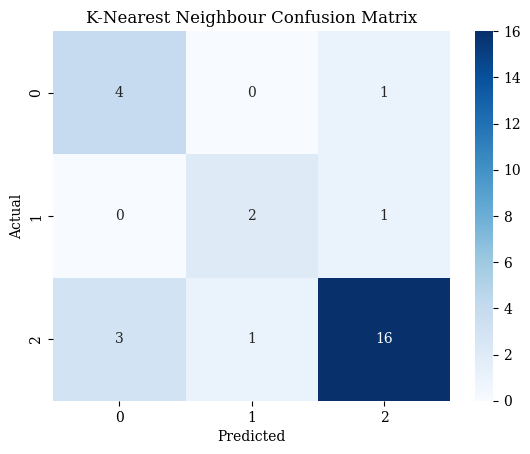

In [ ]:
print("\nK-Nearest Neighbour Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, ypred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('K-Nearest Neighbour Confusion Matrix')
plt.show()

#Content Filtering - Naive Bayes model

## A probabilistic classifier

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import ComplementNB


In [ ]:
X_trainnb, X_testnb, y_trainnb, y_testnb = train_test_split(x_data, y_data, test_size=0.2, random_state = 42)

In [ ]:
nbclassifier = GaussianNB()
nbclassifier.fit(X_trainnb, y_trainnb)

GaussianNB()

In [ ]:
ypred_nb = nbclassifier.predict(X_testnb)

In [ ]:
print("\nNaive Bayes Classification Report:")
print(classification_report(y_testnb, ypred_nb))
print("Confusion Matrix:") # should show all 4 classes
print(confusion_matrix(y_testnb, ypred_nb))


Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       0.75      1.00      0.86         3
           2       1.00      0.90      0.95        20

    accuracy                           0.93        28
   macro avg       0.86      0.97      0.90        28
weighted avg       0.94      0.93      0.93        28

Confusion Matrix:
[[ 5  0  0]
 [ 0  3  0]
 [ 1  1 18]]



Naive Bayes Confusion Matrix:


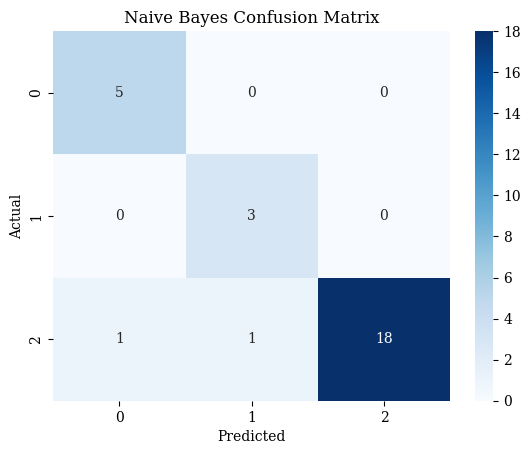

In [ ]:
print("\nNaive Bayes Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, ypred_nb)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

Gaussian performed better with a macro average of 97% recall due to it handling continuous data better than complement naive bayes which has a 53% macro average.

In [ ]:
from sklearn.metrics import roc_curve, auc

#Creating synthetic data

Matching rows of app data

Need to do synthetic without content column then reassign. Also, remember to move content list from machine learning.

In [ ]:
n_synthetic = 4452
synthetic_data = feature_df.sample(n=n_synthetic, replace=True, random_state=42)

In [ ]:
synthetic_data.drop(['Content'], axis=1, inplace = True)

In [ ]:
synthetic_data.shape

(4452, 23)

In [ ]:
synthetic_data

,Gender,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,HA_3,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
102,1,1,1,2,2,3,2,1,3,2,...,3,3,2,2,3,1,1.83,2.00,2.33,2.06
92,1,2,2,2,2,2,2,1,1,2,...,3,1,2,1,1,1,2.00,1.33,1.50,1.61
14,1,4,4,4,4,4,3,4,4,3,...,4,3,2,4,3,3,3.83,3.67,3.17,3.56
106,1,2,2,1,2,2,3,3,2,0,...,1,3,2,1,1,0,2.00,1.50,1.33,1.61
71,1,3,3,2,4,1,1,3,2,4,...,2,1,1,1,2,1,2.33,2.00,1.33,1.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,2,4,3,3,2,1,3,2,2,2,...,2,3,3,2,2,4,2.67,2.17,2.67,2.50
97,1,3,2,1,1,2,3,0,2,1,...,2,1,4,1,4,1,2.00,1.67,2.17,1.94
4,2,1,2,2,0,0,0,3,3,1,...,0,0,2,3,4,4,0.83,2.17,2.17,1.72
108,1,3,3,2,3,3,2,1,2,2,...,3,2,2,1,2,1,2.67,2.00,1.83,2.17


Which algorithms would be useful discuss in report.

Can use naive bayes for probability - k means if I have time

In [ ]:
synthetic_data = synthetic_data.reset_index()

In [ ]:
synthetic_data.drop(['index'], axis=1, inplace=True)

In [ ]:
synthetic_data

,Gender,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,HA_3,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,1,1,1,2,2,3,2,1,3,2,...,3,3,2,2,3,1,1.83,2.00,2.33,2.06
1,1,2,2,2,2,2,2,1,1,2,...,3,1,2,1,1,1,2.00,1.33,1.50,1.61
2,1,4,4,4,4,4,3,4,4,3,...,4,3,2,4,3,3,3.83,3.67,3.17,3.56
3,1,2,2,1,2,2,3,3,2,0,...,1,3,2,1,1,0,2.00,1.50,1.33,1.61
4,1,3,3,2,4,1,1,3,2,4,...,2,1,1,1,2,1,2.33,2.00,1.33,1.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447,2,4,3,3,2,1,3,2,2,2,...,2,3,3,2,2,4,2.67,2.17,2.67,2.50
4448,1,3,2,1,1,2,3,0,2,1,...,2,1,4,1,4,1,2.00,1.67,2.17,1.94
4449,2,1,2,2,0,0,0,3,3,1,...,0,0,2,3,4,4,0.83,2.17,2.17,1.72
4450,1,3,3,2,3,3,2,1,2,2,...,3,2,2,1,2,1,2.67,2.00,1.83,2.17


In [ ]:
synthetic_data.describe()

,Gender,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,HA_3,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
count,4452.000000,4452.000000,4452.000000,4452.000000,4452.000000,4452.000000,4452.000000,4452.000000,4452.000000,4452.000000,...,4452.000000,4452.000000,4452.000000,4452.000000,4452.000000,4452.000000,4452.000000,4452.000000,4452.000000,4452.000000
mean,1.370395,2.086703,2.104447,2.053908,2.104447,2.501572,2.101527,2.204178,2.605346,1.886568,...,2.387466,1.750000,1.997080,1.963836,2.019991,1.364555,2.159317,2.124706,1.913895,2.065889
std,0.482965,0.874067,0.889595,0.992112,0.983626,0.980945,0.952254,0.977091,0.930957,1.009472,...,0.971929,1.004455,1.078055,1.039025,0.975459,1.091554,0.453556,0.593067,0.542489,0.390506
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.830000,1.000000,0.330000,1.500000
25%,1.000000,1.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,...,2.000000,1.000000,1.000000,1.000000,1.000000,0.750000,2.000000,1.830000,1.500000,1.830000
50%,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.170000,2.000000,2.000000,2.000000
75%,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,...,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,2.330000,2.500000,2.170000,2.170000
max,2.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [ ]:
synthetic_data.iloc[199]

,199
Gender,2.00
AT_1,3.00
AT_2,4.00
AT_3,1.00
AT_4,1.00
AT_5,2.00
AT_6,2.00
HA_1,1.00
HA_2,3.00
HA_3,2.00


In [ ]:
synthetic_data.iloc[0]

,0
Gender,1.00
AT_1,1.00
AT_2,1.00
AT_3,2.00
AT_4,2.00
AT_5,3.00
AT_6,2.00
HA_1,1.00
HA_2,3.00
HA_3,2.00


In [ ]:
synthetic_data.dtypes

,0
Gender,int64
AT_1,int64
AT_2,int64
AT_3,int64
AT_4,int64
AT_5,int64
AT_6,int64
HA_1,int64
HA_2,int64
HA_3,int64


In [ ]:
#synthetic_data.to_csv("synthetic_attention_based_questionnaire_responses.csv", index=False)

#Assign Content

In [ ]:
def assign_content(row):
    a = row['1_6 Score']
    b = row['7_12 Score']
    c = row['13_18 Score']

    if 2 <= a < 3 and b < 2 and c < 2:
        return 'Content 1'
    elif 2 <= b < 3 and 2 <= c < 3 and a < 2:
        return 'Content 2'
    elif a >= 3 or b >= 3 or c >= 3 or (2 <= a and b < 3) or (2 <= a and c < 3):
        return 'Content 3'
    else:
        return 'Content 0'

synthetic_data['Content'] = synthetic_data.apply(assign_content, axis=1)

In [ ]:
synthetic_data

,Gender,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,HA_3,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content
0,1,1,1,2,2,3,2,1,3,2,...,3,2,2,3,1,1.83,2.00,2.33,2.06,Content 2
1,1,2,2,2,2,2,2,1,1,2,...,1,2,1,1,1,2.00,1.33,1.50,1.61,Content 1
2,1,4,4,4,4,4,3,4,4,3,...,3,2,4,3,3,3.83,3.67,3.17,3.56,Content 3
3,1,2,2,1,2,2,3,3,2,0,...,3,2,1,1,0,2.00,1.50,1.33,1.61,Content 1
4,1,3,3,2,4,1,1,3,2,4,...,1,1,1,2,1,2.33,2.00,1.33,1.89,Content 3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447,2,4,3,3,2,1,3,2,2,2,...,3,3,2,2,4,2.67,2.17,2.67,2.50,Content 3
4448,1,3,2,1,1,2,3,0,2,1,...,1,4,1,4,1,2.00,1.67,2.17,1.94,Content 3
4449,2,1,2,2,0,0,0,3,3,1,...,0,2,3,4,4,0.83,2.17,2.17,1.72,Content 2
4450,1,3,3,2,3,3,2,1,2,2,...,2,2,1,2,1,2.67,2.00,1.83,2.17,Content 3


In [ ]:
synthetic_data['Content'].value_counts()

,count
Content,
Content 3,2877
Content 1,1017
Content 2,558


In [ ]:
app_df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/COMP-1884-Group Project/app_for_questionnaire.csv')

In [ ]:
#app_df = pd.read_csv("app_for_questionnaire.csv")
#can use code above to read in csv

In [ ]:
synthetic_data = app_df.merge(synthetic_data, left_index=True, right_index=True)

In [ ]:
synthetic_data

,user_id,gender,content_recommendation,content_attributes_with_skill,Gender,AT_1,AT_2,AT_3,AT_4,AT_5,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content
0,172069,male,Content 1,"['algebra', 'hard', 'Write Linear Equation fro...",1,1,1,2,2,3,...,3,2,2,3,1,1.83,2.00,2.33,2.06,Content 2
1,177554,female,Content 2,"['fill_in_1', 'medium', 'Scale Factor']",1,2,2,2,2,2,...,1,2,1,1,1,2.00,1.33,1.50,1.61,Content 1
2,194863,female,Content 0,['no further recommendation'],1,4,4,4,4,4,...,3,2,4,3,3,3.83,3.67,3.17,3.56,Content 3
3,197641,male,Content 2,"['fill_in_1', 'medium', 'Divisibility Rules']",1,2,2,1,2,2,...,3,2,1,1,0,2.00,1.50,1.33,1.61,Content 1
4,201979,male,Content 2,"['fill_in_1', 'medium', 'Divisibility Rules']",1,3,3,2,4,1,...,1,1,1,2,1,2.33,2.00,1.33,1.89,Content 3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447,124955,female,Content 2,"['fill_in_1', 'medium', 'Solving Systems of Li...",2,4,3,3,2,1,...,3,3,2,2,4,2.67,2.17,2.67,2.50,Content 3
4448,183528,male,Content 0,['no further recommendation'],1,3,2,1,1,2,...,1,4,1,4,1,2.00,1.67,2.17,1.94,Content 3
4449,213269,female,Content 1,"['algebra', 'hard', 'Solving Systems of Linear...",2,1,2,2,0,0,...,0,2,3,4,4,0.83,2.17,2.17,1.72,Content 2
4450,216355,male,Content 1,"['algebra', 'hard', 'Solving Systems of Linear...",1,3,3,2,3,3,...,2,2,1,2,1,2.67,2.00,1.83,2.17,Content 3


In [ ]:
synthetic_data.drop(['Gender', 'content_recommendation', 'content_attributes_with_skill'], axis=1, inplace=True)

In [ ]:
synthetic_data

,user_id,gender,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content
0,172069,male,1,1,2,2,3,2,1,3,...,3,2,2,3,1,1.83,2.00,2.33,2.06,Content 2
1,177554,female,2,2,2,2,2,2,1,1,...,1,2,1,1,1,2.00,1.33,1.50,1.61,Content 1
2,194863,female,4,4,4,4,4,3,4,4,...,3,2,4,3,3,3.83,3.67,3.17,3.56,Content 3
3,197641,male,2,2,1,2,2,3,3,2,...,3,2,1,1,0,2.00,1.50,1.33,1.61,Content 1
4,201979,male,3,3,2,4,1,1,3,2,...,1,1,1,2,1,2.33,2.00,1.33,1.89,Content 3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447,124955,female,4,3,3,2,1,3,2,2,...,3,3,2,2,4,2.67,2.17,2.67,2.50,Content 3
4448,183528,male,3,2,1,1,2,3,0,2,...,1,4,1,4,1,2.00,1.67,2.17,1.94,Content 3
4449,213269,female,1,2,2,0,0,0,3,3,...,0,2,3,4,4,0.83,2.17,2.17,1.72,Content 2
4450,216355,male,3,3,2,3,3,2,1,2,...,2,2,1,2,1,2.67,2.00,1.83,2.17,Content 3


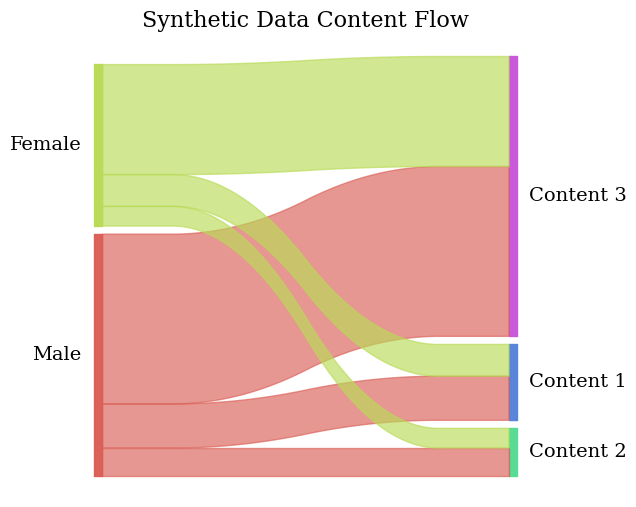

In [ ]:
sankey(left=synthetic_data['gender'].map({'female': 'Female', 'male': 'Male'}), right=synthetic_data['Content'], leftWeight=synthetic_data['1_18 score'],
       rightWeight=synthetic_data['1_18 score'], aspect=20)
plt.title('Synthetic Data Content Flow', fontsize=16)
plt.show()

In [ ]:
cdf2 = synthetic_data.copy()

In [ ]:
cdf2['Content List'] = cdf2['Content'].map(content)

In [ ]:
cdf2

,user_id,gender,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content,Content List
0,172069,male,1,1,2,2,3,2,1,3,...,2,2,3,1,1.83,2.00,2.33,2.06,Content 2,"[quiz, interactive content, ""fill_in_1""]"
1,177554,female,2,2,2,2,2,2,1,1,...,2,1,1,1,2.00,1.33,1.50,1.61,Content 1,"[memory retention, timed quiz, ""algebra""]"
2,194863,female,4,4,4,4,4,3,4,4,...,2,4,3,3,3.83,3.67,3.17,3.56,Content 3,"[simplification, content chunking, ""choose_1""]"
3,197641,male,2,2,1,2,2,3,3,2,...,2,1,1,0,2.00,1.50,1.33,1.61,Content 1,"[memory retention, timed quiz, ""algebra""]"
4,201979,male,3,3,2,4,1,1,3,2,...,1,1,2,1,2.33,2.00,1.33,1.89,Content 3,"[simplification, content chunking, ""choose_1""]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447,124955,female,4,3,3,2,1,3,2,2,...,3,2,2,4,2.67,2.17,2.67,2.50,Content 3,"[simplification, content chunking, ""choose_1""]"
4448,183528,male,3,2,1,1,2,3,0,2,...,4,1,4,1,2.00,1.67,2.17,1.94,Content 3,"[simplification, content chunking, ""choose_1""]"
4449,213269,female,1,2,2,0,0,0,3,3,...,2,3,4,4,0.83,2.17,2.17,1.72,Content 2,"[quiz, interactive content, ""fill_in_1""]"
4450,216355,male,3,3,2,3,3,2,1,2,...,2,1,2,1,2.67,2.00,1.83,2.17,Content 3,"[simplification, content chunking, ""choose_1""]"


In [ ]:
#cdf2.to_csv("synthetic_questionnaire_responses_with_content.csv", index=False)

In [ ]:
content_flow = cdf2['Content'].copy()

In [ ]:
content_flow

,Content
0,Content 2
1,Content 1
2,Content 3
3,Content 1
4,Content 3
...,...
4447,Content 3
4448,Content 3
4449,Content 2
4450,Content 3


In [ ]:
content_flow = app_df.merge(content_flow, left_index=True, right_index=True)

In [ ]:
content_flow['Content List'] = content_flow['Content'].map(content)

In [ ]:
content_flow

,user_id,gender,content_recommendation,content_attributes_with_skill,Content,Content List
0,172069,male,Content 1,"['algebra', 'hard', 'Write Linear Equation fro...",Content 2,"[quiz, interactive content, ""fill_in_1""]"
1,177554,female,Content 2,"['fill_in_1', 'medium', 'Scale Factor']",Content 1,"[memory retention, timed quiz, ""algebra""]"
2,194863,female,Content 0,['no further recommendation'],Content 3,"[simplification, content chunking, ""choose_1""]"
3,197641,male,Content 2,"['fill_in_1', 'medium', 'Divisibility Rules']",Content 1,"[memory retention, timed quiz, ""algebra""]"
4,201979,male,Content 2,"['fill_in_1', 'medium', 'Divisibility Rules']",Content 3,"[simplification, content chunking, ""choose_1""]"
...,...,...,...,...,...,...
4447,124955,female,Content 2,"['fill_in_1', 'medium', 'Solving Systems of Li...",Content 3,"[simplification, content chunking, ""choose_1""]"
4448,183528,male,Content 0,['no further recommendation'],Content 3,"[simplification, content chunking, ""choose_1""]"
4449,213269,female,Content 1,"['algebra', 'hard', 'Solving Systems of Linear...",Content 2,"[quiz, interactive content, ""fill_in_1""]"
4450,216355,male,Content 1,"['algebra', 'hard', 'Solving Systems of Linear...",Content 3,"[simplification, content chunking, ""choose_1""]"


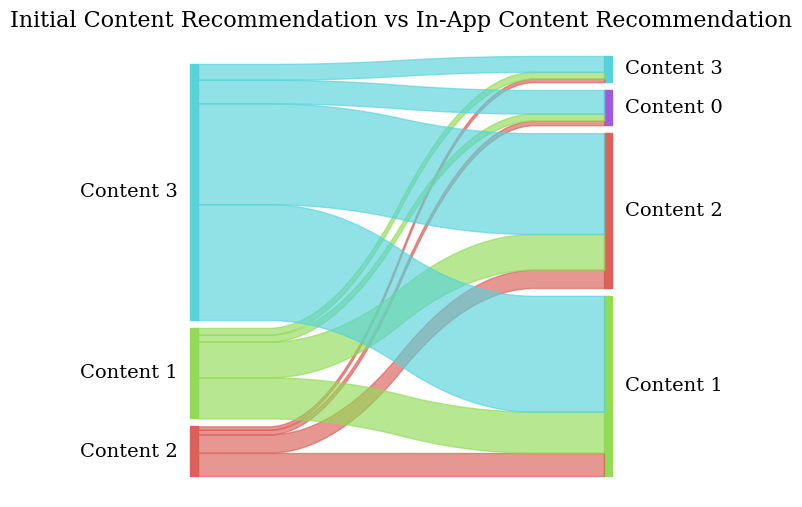

In [ ]:
sankey(left=content_flow['Content'], right=content_flow['content_recommendation'], aspect=20)
plt.title('Initial Content Recommendation vs In-App Content Recommendation', fontsize=16)
plt.show()

Most users in this dataset with iniially content 3 were recommended in app content 1 and content 2.

In [ ]:
content_flow['content_recommendation'].value_counts()

,count
content_recommendation,
Content 1,2024
Content 2,1739
Content 0,396
Content 3,293


In [ ]:
content_flow['Content'].value_counts()

,count
Content,
Content 3,2877
Content 1,1017
Content 2,558


#K Nearest Neighbour Synthetic data - Collaborative Filtering

In [ ]:
synthetic_model = synthetic_data.copy()

In [ ]:
le = LabelEncoder()
synthetic_model['Content'] = le.fit_transform(synthetic_model['Content'])

print(synthetic_model['Content'])

0       1
1       0
2       2
3       0
4       2
       ..
4447    2
4448    2
4449    1
4450    2
4451    2
Name: Content, Length: 4452, dtype: int64


In [ ]:
cdf2

,user_id,gender,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content,Content List
0,172069,male,1,1,2,2,3,2,1,3,...,2,2,3,1,1.83,2.00,2.33,2.06,Content 2,"[quiz, interactive content, ""fill_in_1""]"
1,177554,female,2,2,2,2,2,2,1,1,...,2,1,1,1,2.00,1.33,1.50,1.61,Content 1,"[memory retention, timed quiz, ""algebra""]"
2,194863,female,4,4,4,4,4,3,4,4,...,2,4,3,3,3.83,3.67,3.17,3.56,Content 3,"[simplification, content chunking, ""choose_1""]"
3,197641,male,2,2,1,2,2,3,3,2,...,2,1,1,0,2.00,1.50,1.33,1.61,Content 1,"[memory retention, timed quiz, ""algebra""]"
4,201979,male,3,3,2,4,1,1,3,2,...,1,1,2,1,2.33,2.00,1.33,1.89,Content 3,"[simplification, content chunking, ""choose_1""]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447,124955,female,4,3,3,2,1,3,2,2,...,3,2,2,4,2.67,2.17,2.67,2.50,Content 3,"[simplification, content chunking, ""choose_1""]"
4448,183528,male,3,2,1,1,2,3,0,2,...,4,1,4,1,2.00,1.67,2.17,1.94,Content 3,"[simplification, content chunking, ""choose_1""]"
4449,213269,female,1,2,2,0,0,0,3,3,...,2,3,4,4,0.83,2.17,2.17,1.72,Content 2,"[quiz, interactive content, ""fill_in_1""]"
4450,216355,male,3,3,2,3,3,2,1,2,...,2,1,2,1,2.67,2.00,1.83,2.17,Content 3,"[simplification, content chunking, ""choose_1""]"


Content 1 = 0

Content 2 = 1

Content 3 = 2

In [ ]:
synthetic_model

,user_id,gender,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content
0,172069,male,1,1,2,2,3,2,1,3,...,3,2,2,3,1,1.83,2.00,2.33,2.06,1
1,177554,female,2,2,2,2,2,2,1,1,...,1,2,1,1,1,2.00,1.33,1.50,1.61,0
2,194863,female,4,4,4,4,4,3,4,4,...,3,2,4,3,3,3.83,3.67,3.17,3.56,2
3,197641,male,2,2,1,2,2,3,3,2,...,3,2,1,1,0,2.00,1.50,1.33,1.61,0
4,201979,male,3,3,2,4,1,1,3,2,...,1,1,1,2,1,2.33,2.00,1.33,1.89,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447,124955,female,4,3,3,2,1,3,2,2,...,3,3,2,2,4,2.67,2.17,2.67,2.50,2
4448,183528,male,3,2,1,1,2,3,0,2,...,1,4,1,4,1,2.00,1.67,2.17,1.94,2
4449,213269,female,1,2,2,0,0,0,3,3,...,0,2,3,4,4,0.83,2.17,2.17,1.72,1
4450,216355,male,3,3,2,3,3,2,1,2,...,2,2,1,2,1,2.67,2.00,1.83,2.17,2


Gender is nominal data therefore will be using one hot encoding.

One-hot encoding

In [ ]:
#One-Hot Encoding

encoder=ce.OneHotEncoder(cols='gender',handle_unknown='return_nan',return_df=True,use_cat_names=True)

gender_encoded = encoder.fit_transform(synthetic_model['gender'])

In [ ]:
synthetic_model = gender_encoded.merge(synthetic_model, left_index=True, right_index=True)

In [ ]:
synthetic_model

,gender_male,gender_female,user_id,gender,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content
0,1.0,0.0,172069,male,1,1,2,2,3,2,...,3,2,2,3,1,1.83,2.00,2.33,2.06,1
1,0.0,1.0,177554,female,2,2,2,2,2,2,...,1,2,1,1,1,2.00,1.33,1.50,1.61,0
2,0.0,1.0,194863,female,4,4,4,4,4,3,...,3,2,4,3,3,3.83,3.67,3.17,3.56,2
3,1.0,0.0,197641,male,2,2,1,2,2,3,...,3,2,1,1,0,2.00,1.50,1.33,1.61,0
4,1.0,0.0,201979,male,3,3,2,4,1,1,...,1,1,1,2,1,2.33,2.00,1.33,1.89,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447,0.0,1.0,124955,female,4,3,3,2,1,3,...,3,3,2,2,4,2.67,2.17,2.67,2.50,2
4448,1.0,0.0,183528,male,3,2,1,1,2,3,...,1,4,1,4,1,2.00,1.67,2.17,1.94,2
4449,0.0,1.0,213269,female,1,2,2,0,0,0,...,0,2,3,4,4,0.83,2.17,2.17,1.72,1
4450,1.0,0.0,216355,male,3,3,2,3,3,2,...,2,2,1,2,1,2.67,2.00,1.83,2.17,2


In [ ]:
synthetic_model.drop(['gender'], axis=1, inplace=True)

In [ ]:
synthetic_model.drop(['user_id'], axis=1, inplace=True)

In [ ]:
synthetic_model

,gender_male,gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content
0,1.0,0.0,1,1,2,2,3,2,1,3,...,3,2,2,3,1,1.83,2.00,2.33,2.06,1
1,0.0,1.0,2,2,2,2,2,2,1,1,...,1,2,1,1,1,2.00,1.33,1.50,1.61,0
2,0.0,1.0,4,4,4,4,4,3,4,4,...,3,2,4,3,3,3.83,3.67,3.17,3.56,2
3,1.0,0.0,2,2,1,2,2,3,3,2,...,3,2,1,1,0,2.00,1.50,1.33,1.61,0
4,1.0,0.0,3,3,2,4,1,1,3,2,...,1,1,1,2,1,2.33,2.00,1.33,1.89,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447,0.0,1.0,4,3,3,2,1,3,2,2,...,3,3,2,2,4,2.67,2.17,2.67,2.50,2
4448,1.0,0.0,3,2,1,1,2,3,0,2,...,1,4,1,4,1,2.00,1.67,2.17,1.94,2
4449,0.0,1.0,1,2,2,0,0,0,3,3,...,0,2,3,4,4,0.83,2.17,2.17,1.72,1
4450,1.0,0.0,3,3,2,3,3,2,1,2,...,2,2,1,2,1,2.67,2.00,1.83,2.17,2


In [ ]:
y_df = synthetic_model['Content']
x_df = synthetic_model.copy()
x_df.drop(['Content'],axis=1, inplace = True)

In [ ]:
y_df

,Content
0,1
1,0
2,2
3,0
4,2
...,...
4447,2
4448,2
4449,1
4450,2


In [ ]:
x_df

,gender_male,gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,1.0,0.0,1,1,2,2,3,2,1,3,...,3,3,2,2,3,1,1.83,2.00,2.33,2.06
1,0.0,1.0,2,2,2,2,2,2,1,1,...,3,1,2,1,1,1,2.00,1.33,1.50,1.61
2,0.0,1.0,4,4,4,4,4,3,4,4,...,4,3,2,4,3,3,3.83,3.67,3.17,3.56
3,1.0,0.0,2,2,1,2,2,3,3,2,...,1,3,2,1,1,0,2.00,1.50,1.33,1.61
4,1.0,0.0,3,3,2,4,1,1,3,2,...,2,1,1,1,2,1,2.33,2.00,1.33,1.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447,0.0,1.0,4,3,3,2,1,3,2,2,...,2,3,3,2,2,4,2.67,2.17,2.67,2.50
4448,1.0,0.0,3,2,1,1,2,3,0,2,...,2,1,4,1,4,1,2.00,1.67,2.17,1.94
4449,0.0,1.0,1,2,2,0,0,0,3,3,...,0,0,2,3,4,4,0.83,2.17,2.17,1.72
4450,1.0,0.0,3,3,2,3,3,2,1,2,...,3,2,2,1,2,1,2.67,2.00,1.83,2.17


In [ ]:
MinMaxScaler = preprocessing.MinMaxScaler()
minmax_x_df = MinMaxScaler.fit_transform(x_df)
#using standard scaler as it yields better results than minmax scaler in precision and f1_score - recall is the same
x_df

,gender_male,gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,1.0,0.0,1,1,2,2,3,2,1,3,...,3,3,2,2,3,1,1.83,2.00,2.33,2.06
1,0.0,1.0,2,2,2,2,2,2,1,1,...,3,1,2,1,1,1,2.00,1.33,1.50,1.61
2,0.0,1.0,4,4,4,4,4,3,4,4,...,4,3,2,4,3,3,3.83,3.67,3.17,3.56
3,1.0,0.0,2,2,1,2,2,3,3,2,...,1,3,2,1,1,0,2.00,1.50,1.33,1.61
4,1.0,0.0,3,3,2,4,1,1,3,2,...,2,1,1,1,2,1,2.33,2.00,1.33,1.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447,0.0,1.0,4,3,3,2,1,3,2,2,...,2,3,3,2,2,4,2.67,2.17,2.67,2.50
4448,1.0,0.0,3,2,1,1,2,3,0,2,...,2,1,4,1,4,1,2.00,1.67,2.17,1.94
4449,0.0,1.0,1,2,2,0,0,0,3,3,...,0,0,2,3,4,4,0.83,2.17,2.17,1.72
4450,1.0,0.0,3,3,2,3,3,2,1,2,...,3,2,2,1,2,1,2.67,2.00,1.83,2.17


In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(minmax_x_df,y_df, test_size=0.2, random_state = 42)
knn_clf=KNeighborsClassifier(n_neighbors=3)
knn_clf.fit(X_train2,y_train2)
ypred2=knn_clf.predict(X_test2) #These are the predicted output values

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("\n Synthetic K-Nearest Neighbour Classification Report:")
print(classification_report(y_test2, ypred2))
print("Confusion Matrix:") # should show all 3 classes
print(confusion_matrix(y_test2, ypred2))


 Synthetic K-Nearest Neighbour Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       206
           1       1.00      1.00      1.00       120
           2       1.00      1.00      1.00       565

    accuracy                           1.00       891
   macro avg       1.00      1.00      1.00       891
weighted avg       1.00      1.00      1.00       891

Confusion Matrix:
[[206   0   0]
 [  0 120   0]
 [  0   0 565]]



 Synthetic K-Nearest Neighbour Confusion Matrix:


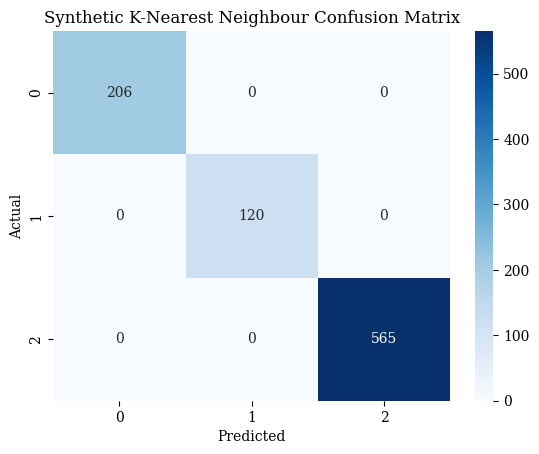

In [ ]:
print("\n Synthetic K-Nearest Neighbour Confusion Matrix:")
conf_matrix = confusion_matrix(y_test2, ypred2)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Synthetic K-Nearest Neighbour Confusion Matrix')
plt.show()

#Content Filtering Synthetic Data - Training the Naive Bayes model on the Training set

## A probabilistic classifier

There is a limitation with naive bayes as it assumes all features are independant of eachother.

In machine learning, especially for multiclass classification, predict vs. predict_proba functions offer different outputs. predict returns the predicted class label, while predict_proba returns a probability distribution over all possible classes.

In [ ]:
from sklearn.naive_bayes import GaussianNB
nbclassifier = GaussianNB()
nbclassifier.fit(X_train2, y_train2)


GaussianNB()

## Predicting the Test set results

In [ ]:
y_pred_nb = nbclassifier.predict(X_test2)


## Making the Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
print("\nSynthetic Naive Bayes Classification Report:")
print(classification_report(y_test2, y_pred_nb))
print("Confusion Matrix:")  # should show all 3 classes
print(confusion_matrix(y_test2, y_pred_nb))


Synthetic Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       206
           1       0.58      1.00      0.73       120
           2       1.00      0.77      0.87       565

    accuracy                           0.85       891
   macro avg       0.80      0.92      0.83       891
weighted avg       0.90      0.85      0.86       891

Confusion Matrix:
[[206   0   0]
 [  0 120   0]
 [ 45  87 433]]


True positives are in the diagonal of the confusion matrix.


Synthetic Naive Bayes Confusion Matrix:


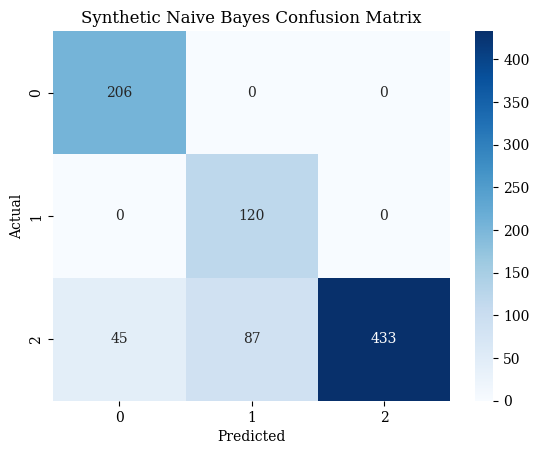

In [ ]:
print("\nSynthetic Naive Bayes Confusion Matrix:")
conf_matrix = confusion_matrix(y_test2, y_pred_nb)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Synthetic Naive Bayes Confusion Matrix')
plt.show()

Naive Bayes Results:

Original data had 100% recall for content 1 and 2. Content 3 had 90% recall. Content 3 has highest support (20, content 1 having 2 and content 2 having 3).

Recall macro average was 97%.

Synthetic data had more data and performed better with it as suggested in a literature. Recall macro average was 92%. Content 1 and 2 had 100% recall and content 3 had 77% recall.

## Oversampling using SMOTE (Synthetic Minority Over-sampling Technique)

In [ ]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE

In [ ]:
oversample = SMOTE()
x_resampled, y_resampled = oversample.fit_resample(x_df, y_df)

In [ ]:
print (y_resampled.value_counts())

Content
1    2877
0    2877
2    2877
Name: count, dtype: int64


In [ ]:
y_resampled

,Content
0,1
1,0
2,2
3,0
4,2
...,...
8626,1
8627,1
8628,1
8629,1


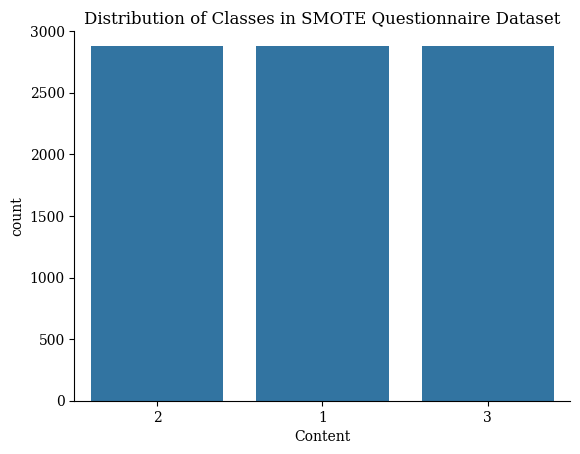

In [ ]:
sns.countplot(x=y_resampled.map({0: '1', 1: '2', 2: '3'}))
plt.title('Distribution of Classes in SMOTE Questionnaire Dataset')
plt.ylim(0, 3000)
for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
      if spine.spine_type != 'bottom' and spine.spine_type != 'left':
        spine.set_visible(False)
plt.show()

In [ ]:
y_resampled

,Content
0,1
1,0
2,2
3,0
4,2
...,...
8626,1
8627,1
8628,1
8629,1


##Creating new dataframe of smote balanced synthetic data.

In [ ]:
SMOTEbalanced_syndata = pd.DataFrame(x_resampled)

In [ ]:
SMOTEbalanced_syndata

,gender_male,gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,1.0,0.0,1,1,2,2,3,2,1,3,...,3,3,2,2,3,1,1.83,2.00,2.33,2.06
1,0.0,1.0,2,2,2,2,2,2,1,1,...,3,1,2,1,1,1,2.00,1.33,1.50,1.61
2,0.0,1.0,4,4,4,4,4,3,4,4,...,4,3,2,4,3,3,3.83,3.67,3.17,3.56
3,1.0,0.0,2,2,1,2,2,3,3,2,...,1,3,2,1,1,0,2.00,1.50,1.33,1.61
4,1.0,0.0,3,3,2,4,1,1,3,2,...,2,1,1,1,2,1,2.33,2.00,1.33,1.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8626,0.0,1.0,1,2,2,0,0,0,3,3,...,0,0,2,3,4,4,0.83,2.17,2.17,1.72
8627,1.0,0.0,0,0,0,2,2,2,2,3,...,1,3,2,3,2,3,1.00,2.17,2.33,1.83
8628,0.0,1.0,1,2,2,0,0,0,3,3,...,0,0,2,3,4,4,0.83,2.17,2.17,1.72
8629,0.0,1.0,2,3,1,0,2,2,3,2,...,2,1,3,2,3,2,1.67,2.00,2.17,1.94


In [ ]:
target = y_resampled.to_frame(name='Target')

In [ ]:
print(target.value_counts())

Target
0         2877
1         2877
2         2877
Name: count, dtype: int64


In [ ]:
SMOTEbalanced_syndata = SMOTEbalanced_syndata.merge(target, left_index=True, right_index=True)

In [ ]:
SMOTEbalanced_syndata

,gender_male,gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Target
0,1.0,0.0,1,1,2,2,3,2,1,3,...,3,2,2,3,1,1.83,2.00,2.33,2.06,1
1,0.0,1.0,2,2,2,2,2,2,1,1,...,1,2,1,1,1,2.00,1.33,1.50,1.61,0
2,0.0,1.0,4,4,4,4,4,3,4,4,...,3,2,4,3,3,3.83,3.67,3.17,3.56,2
3,1.0,0.0,2,2,1,2,2,3,3,2,...,3,2,1,1,0,2.00,1.50,1.33,1.61,0
4,1.0,0.0,3,3,2,4,1,1,3,2,...,1,1,1,2,1,2.33,2.00,1.33,1.89,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8626,0.0,1.0,1,2,2,0,0,0,3,3,...,0,2,3,4,4,0.83,2.17,2.17,1.72,1
8627,1.0,0.0,0,0,0,2,2,2,2,3,...,3,2,3,2,3,1.00,2.17,2.33,1.83,1
8628,0.0,1.0,1,2,2,0,0,0,3,3,...,0,2,3,4,4,0.83,2.17,2.17,1.72,1
8629,0.0,1.0,2,3,1,0,2,2,3,2,...,1,3,2,3,2,1.67,2.00,2.17,1.94,1


##Creating csv file of smote balanced data

In [ ]:
SMOTEbalanced_syndata.to_csv("SMOTEbalanced_syndata.csv", index=False)

In [ ]:
x_smote = SMOTEbalanced_syndata.drop(columns=['Target'])
y_smote = SMOTEbalanced_syndata['Target']

In [ ]:
MinMaxScaler = preprocessing.MinMaxScaler()
RobustScaler = preprocessing.RobustScaler()
minmax_x_smote = MinMaxScaler.fit_transform(x_smote)
robust_x_smote = RobustScaler.fit_transform(x_smote)
#minmax scaler is better with k nearest neighbour
#robust scaler works well for balanced classes, however it turns some numbers into negatives which can't be used with naive bayes
minmax_x_smote

array([[1.        , 0.        , 0.25      , ..., 0.33333333, 0.54495913,
        0.224     ],
       [0.        , 1.        , 0.5       , ..., 0.11      , 0.31880109,
        0.044     ],
       [0.        , 1.        , 1.        , ..., 0.89      , 0.77384196,
        0.824     ],
       ...,
       [0.        , 1.        , 0.25      , ..., 0.39      , 0.5013624 ,
        0.088     ],
       [0.        , 1.        , 0.5       , ..., 0.33333333, 0.5013624 ,
        0.176     ],
       [1.        , 0.        , 0.5       , ..., 0.5       , 0.5013624 ,
        0.268     ]])

In [ ]:
x_train, x_test, y_trainsmote, y_testsmote = train_test_split(robust_x_smote, y_smote, test_size=0.2, random_state=42)


In [ ]:
knn_clf.fit(x_train, y_trainsmote)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
x_trainnb2, x_testnb2, y_trainnb2, y_testnb2 = train_test_split(x_smote, y_smote, test_size=0.2, random_state=42)

In [ ]:
nbclassifier.fit(x_train, y_trainsmote)

GaussianNB()

In [ ]:
ypred_knn2=knn_clf.predict(x_test)
ypred_nb2 = nbclassifier.predict(x_test)

In [ ]:
print("\nBalanced K-Nearest Neighbour Classification Report:")
print(classification_report(y_testsmote, ypred_knn2))
print("Confusion Matrix:") # should show all 3 classes
print(confusion_matrix(y_testsmote, ypred_knn2))


Balanced K-Nearest Neighbour Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       608
           1       1.00      1.00      1.00       570
           2       1.00      1.00      1.00       549

    accuracy                           1.00      1727
   macro avg       1.00      1.00      1.00      1727
weighted avg       1.00      1.00      1.00      1727

Confusion Matrix:
[[608   0   0]
 [  0 570   0]
 [  0   0 549]]



 Balanced K-Nearest Neighbour Confusion Matrix:


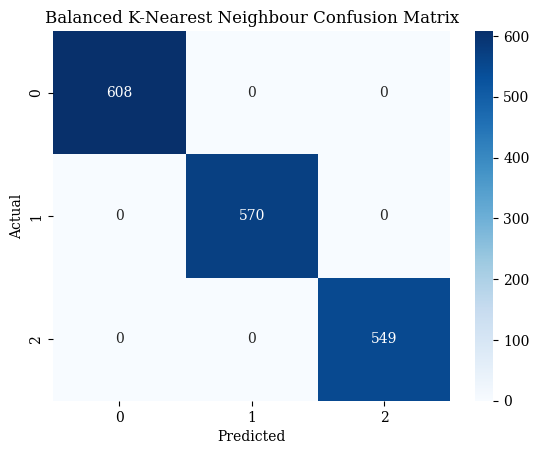

In [ ]:
print("\n Balanced K-Nearest Neighbour Confusion Matrix:")
conf_matrix = confusion_matrix(y_testsmote, ypred_knn2)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Balanced K-Nearest Neighbour Confusion Matrix')
plt.show()

Overfiting could be due to the synthetic data used. Sample is too small for there to be a big variance in data.

In [ ]:
print("\nBalanced Naive Bayes Classification Report:")
print(classification_report(y_testsmote, ypred_nb2))
print("Confusion Matrix:")  # should show all 3 classes
print(confusion_matrix(y_testsmote, ypred_nb2))


Balanced Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       608
           1       0.83      1.00      0.91       570
           2       1.00      0.71      0.83       549

    accuracy                           0.91      1727
   macro avg       0.92      0.90      0.90      1727
weighted avg       0.92      0.91      0.90      1727

Confusion Matrix:
[[608   0   0]
 [  0 570   0]
 [ 42 119 388]]


True positives are in the diagonal of the confusion matrix.


 Balanced Naive Bayes Confusion Matrix:


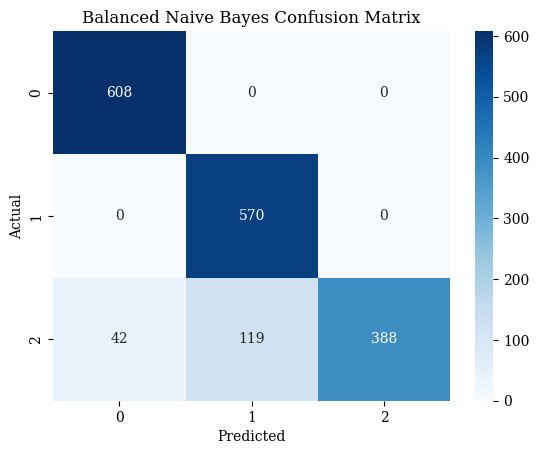

In [ ]:
print("\n Balanced Naive Bayes Confusion Matrix:")
conf_matrix = confusion_matrix(y_testsmote, ypred_nb2)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Balanced Naive Bayes Confusion Matrix')
plt.show()

#Original Dataset (with asymptomatic) Feature Selection and Machine Learning (KNN and Naive Bayes)

In [ ]:
cdf_feat = cdf.copy()

In [ ]:
cdf_feat.drop(['Age', 'No of Siblings ', 'Family Type',
       'Father education level', 'Mother education level',
       'Hosteler/Day scholar'], axis=1, inplace=True)

In [ ]:
cdf_ml = cdf_feat.copy()

In [ ]:
cdf_ml.drop(['Content List'], axis=1, inplace=True)

In [ ]:
le = LabelEncoder()
cdf_ml['Content'] = le.fit_transform(cdf_ml['Content'])

print(cdf_ml['Content'])

0      3
1      1
2      0
3      0
4      2
      ..
333    0
334    3
335    0
336    3
337    0
Name: Content, Length: 338, dtype: int64


Content 1 = 0

Content 2 = 1

Content 3 = 2

In [ ]:
cdf_ml

,Gender,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,HA_3,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content
0,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,3
1,2,2,2,2,3,3,2,2,3,1,...,1,2,2,3,1,2.33,1.67,1.83,1.94,1
2,1,0,0,0,0,0,0,0,1,1,...,4,2,0,0,0,0.00,1.67,1.67,1.11,0
3,1,2,1,1,2,1,2,1,3,1,...,1,0,0,1,0,1.50,1.50,0.67,1.22,0
4,2,1,2,2,2,2,2,2,2,2,...,2,2,2,2,2,1.83,2.00,2.00,1.94,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,2,1,1,1,1,1,1,1,2,1,...,1,1,1,1,1,1.00,1.17,1.00,1.06,0
334,1,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,3
335,2,1,1,1,2,1,2,1,1,1,...,1,1,2,0,1,1.33,1.00,1.00,1.11,0
336,1,3,3,1,2,4,3,3,4,1,...,3,0,3,2,0,2.67,2.17,1.50,2.11,3


Gender is nominal data therefore will be using one hot encoding.

One-hot encoding

In [ ]:
#One-Hot Encoding

#encoder=ce.OneHotEncoder(cols='Gender',handle_unknown='return_nan',return_df=True,use_cat_names=True)

#cdfgender_encoded = encoder.fit_transform(cdf_ml['Gender'])

In [ ]:
#cdf_ml = cdfgender_encoded.merge(cdf_ml, left_index=True, right_index=True)

In [ ]:
cdf_ml

,Gender,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,HA_3,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content
0,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,3
1,2,2,2,2,3,3,2,2,3,1,...,1,2,2,3,1,2.33,1.67,1.83,1.94,1
2,1,0,0,0,0,0,0,0,1,1,...,4,2,0,0,0,0.00,1.67,1.67,1.11,0
3,1,2,1,1,2,1,2,1,3,1,...,1,0,0,1,0,1.50,1.50,0.67,1.22,0
4,2,1,2,2,2,2,2,2,2,2,...,2,2,2,2,2,1.83,2.00,2.00,1.94,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,2,1,1,1,1,1,1,1,2,1,...,1,1,1,1,1,1.00,1.17,1.00,1.06,0
334,1,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,3
335,2,1,1,1,2,1,2,1,1,1,...,1,1,2,0,1,1.33,1.00,1.00,1.11,0
336,1,3,3,1,2,4,3,3,4,1,...,3,0,3,2,0,2.67,2.17,1.50,2.11,3


In [ ]:
cdf_ml.drop(['Gender'], axis=1, inplace=True)

In [ ]:
y_cdf = cdf_ml['Content']
x_cdf = cdf_ml.copy()
x_cdf.drop(['Content'],axis=1, inplace = True)

In [ ]:
y_cdf

,Content
0,3
1,1
2,0
3,0
4,2
...,...
333,0
334,3
335,0
336,3


In [ ]:
x_cdf

,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,HA_3,HA_4,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00
1,2,2,2,3,3,2,2,3,1,1,...,2,1,2,2,3,1,2.33,1.67,1.83,1.94
2,0,0,0,0,0,0,0,1,1,2,...,4,4,2,0,0,0,0.00,1.67,1.67,1.11
3,2,1,1,2,1,2,1,3,1,1,...,2,1,0,0,1,0,1.50,1.50,0.67,1.22
4,1,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,1.83,2.00,2.00,1.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,1,1,1,1,1,1,1,2,1,1,...,1,1,1,1,1,1,1.00,1.17,1.00,1.06
334,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00
335,1,1,1,2,1,2,1,1,1,1,...,1,1,1,2,0,1,1.33,1.00,1.00,1.11
336,3,3,1,2,4,3,3,4,1,1,...,1,3,0,3,2,0,2.67,2.17,1.50,2.11


In [ ]:
MinMaxScaler = preprocessing.MinMaxScaler()
minmax_x_cdf = MinMaxScaler.fit_transform(x_cdf)
RobustScaler = preprocessing.RobustScaler()
robust_x_cdf = RobustScaler.fit_transform(x_cdf)
sc = StandardScaler()
sc_x_cdf = sc.fit_transform(x_cdf)


In [ ]:
minmax_x_cdf

array([[0.5   , 0.5   , 0.5   , ..., 0.5   , 0.5   , 0.5   ],
       [0.5   , 0.5   , 0.5   , ..., 0.4175, 0.4575, 0.485 ],
       [0.    , 0.    , 0.    , ..., 0.4175, 0.4175, 0.2775],
       ...,
       [0.25  , 0.25  , 0.25  , ..., 0.25  , 0.25  , 0.2775],
       [0.75  , 0.75  , 0.25  , ..., 0.5425, 0.375 , 0.5275],
       [0.5   , 0.25  , 0.25  , ..., 0.375 , 0.2925, 0.32  ]])

#Original dataset (338 rows) KNN

In [ ]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(sc_x_cdf,y_cdf, test_size=0.2, random_state = 42)
knn_clf=KNeighborsClassifier(n_neighbors=3)
knn_clf.fit(X_train3,y_train3)
ypred3=knn_clf.predict(X_test3) #These are the predicted output values

In [ ]:
knn_clf.fit(X_train3,y_train3)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("\n Original Dataset K-Nearest Neighbour Classification Report:")
print(classification_report(y_test3, ypred3))
print("Confusion Matrix:") # should show all 3 classes
print(confusion_matrix(y_test3, ypred3))


 Original Dataset K-Nearest Neighbour Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        43
           1       0.40      0.67      0.50         3
           2       0.00      0.00      0.00         1
           3       0.92      0.57      0.71        21

    accuracy                           0.82        68
   macro avg       0.56      0.55      0.54        68
weighted avg       0.88      0.82      0.84        68

Confusion Matrix:
[[42  0  1  0]
 [ 1  2  0  0]
 [ 0  0  0  1]
 [ 3  3  3 12]]


#Original dataset Naive Bayes

In [ ]:
nbclassifier.fit(X_train3,y_train3)

GaussianNB()

In [ ]:
ypred_nb3 = nbclassifier.predict(X_test3)

In [ ]:
print("\nOriginal dataset Naive Bayes Classification Report:")
print(classification_report(y_test3, ypred_nb3))
print("Confusion Matrix:")  # should show all 3 classes
print(confusion_matrix(y_test3, ypred_nb3))


Original dataset Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.93        43
           1       0.43      1.00      0.60         3
           2       0.17      1.00      0.29         1
           3       0.94      0.81      0.87        21

    accuracy                           0.85        68
   macro avg       0.63      0.92      0.67        68
weighted avg       0.95      0.85      0.88        68

Confusion Matrix:
[[37  2  3  1]
 [ 0  3  0  0]
 [ 0  0  1  0]
 [ 0  2  2 17]]


In [ ]:
#cdf_feat.to_csv("original_content_questionnaire.csv", index=False)

#SMOTE Original Symptomatic dataset



In [ ]:
model_df

,Gender_male,Gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Content
0,1.0,0.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,2
1,1.0,0.0,2,2,2,3,3,2,2,3,...,1,2,2,3,1,2.33,1.67,1.83,1.94,0
2,1.0,0.0,1,2,2,2,2,2,2,2,...,2,2,2,2,2,1.83,2.00,2.00,1.94,1
3,1.0,0.0,2,3,2,2,2,2,2,2,...,2,3,3,2,2,2.17,2.17,2.50,2.28,2
4,1.0,0.0,1,2,2,0,0,0,3,3,...,0,2,3,4,4,0.83,2.17,2.17,1.72,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.0,1.0,3,2,3,4,0,1,2,2,...,2,0,4,2,0,2.17,1.33,1.67,1.72,0
135,0.0,1.0,3,2,3,4,0,1,2,2,...,2,0,4,2,0,2.17,1.33,1.67,1.72,0
136,1.0,0.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,2
137,0.0,1.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.00,2.00,2.00,2.00,2


In [ ]:
x_data

,Gender_male,Gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,1.0,0.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00
1,1.0,0.0,2,2,2,3,3,2,2,3,...,2,1,2,2,3,1,2.33,1.67,1.83,1.94
2,1.0,0.0,1,2,2,2,2,2,2,2,...,2,2,2,2,2,2,1.83,2.00,2.00,1.94
3,1.0,0.0,2,3,2,2,2,2,2,2,...,3,2,3,3,2,2,2.17,2.17,2.50,2.28
4,1.0,0.0,1,2,2,0,0,0,3,3,...,0,0,2,3,4,4,0.83,2.17,2.17,1.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.0,1.0,3,2,3,4,0,1,2,2,...,2,2,0,4,2,0,2.17,1.33,1.67,1.72
135,0.0,1.0,3,2,3,4,0,1,2,2,...,2,2,0,4,2,0,2.17,1.33,1.67,1.72
136,1.0,0.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00
137,0.0,1.0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.00,2.00,2.00,2.00


In [ ]:
y_data

,Content
0,2
1,0
2,1
3,2
4,1
...,...
134,0
135,0
136,2
137,2


In [ ]:
oversample = SMOTE()
x_balanced, y_balanced = oversample.fit_resample(x_data, y_data)

In [ ]:
print (y_balanced.value_counts())

Content
2    89
0    89
1    89
Name: count, dtype: int64


In [ ]:
x_balanced

,Gender_male,Gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,1.000000,0.000000,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.000000,2.000000,2.000000,2.000000
1,1.000000,0.000000,2,2,2,3,3,2,2,3,...,2,1,2,2,3,1,2.330000,1.670000,1.830000,1.940000
2,1.000000,0.000000,1,2,2,2,2,2,2,2,...,2,2,2,2,2,2,1.830000,2.000000,2.000000,1.940000
3,1.000000,0.000000,2,3,2,2,2,2,2,2,...,3,2,3,3,2,2,2.170000,2.170000,2.500000,2.280000
4,1.000000,0.000000,1,2,2,0,0,0,3,3,...,0,0,2,3,4,4,0.830000,2.170000,2.170000,1.720000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,0.422160,0.577840,1,2,2,2,2,2,2,2,...,2,2,2,2,2,2,1.830000,2.000000,2.000000,1.940000
263,0.000000,1.000000,1,1,2,2,2,2,1,3,...,2,2,2,2,2,1,1.830000,2.073526,2.256474,2.060000
264,0.000000,1.000000,1,0,1,0,2,2,1,3,...,3,1,2,3,2,0,1.430266,2.302828,2.130133,1.957038
265,0.274201,0.725799,1,1,2,2,1,2,2,2,...,2,1,2,2,2,2,1.739514,2.000000,2.046614,1.926290


In [ ]:
x_balanced["Gender_male"] = x_balanced["Gender_male"].astype(int)

In [ ]:
x_balanced["Gender_female"] = x_balanced["Gender_female"].astype(int)

In [ ]:
x_balanced

,Gender_male,Gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,1,0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.000000,2.000000,2.000000,2.000000
1,1,0,2,2,2,3,3,2,2,3,...,2,1,2,2,3,1,2.330000,1.670000,1.830000,1.940000
2,1,0,1,2,2,2,2,2,2,2,...,2,2,2,2,2,2,1.830000,2.000000,2.000000,1.940000
3,1,0,2,3,2,2,2,2,2,2,...,3,2,3,3,2,2,2.170000,2.170000,2.500000,2.280000
4,1,0,1,2,2,0,0,0,3,3,...,0,0,2,3,4,4,0.830000,2.170000,2.170000,1.720000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,0,0,1,2,2,2,2,2,2,2,...,2,2,2,2,2,2,1.830000,2.000000,2.000000,1.940000
263,0,1,1,1,2,2,2,2,1,3,...,2,2,2,2,2,1,1.830000,2.073526,2.256474,2.060000
264,0,1,1,0,1,0,2,2,1,3,...,3,1,2,3,2,0,1.430266,2.302828,2.130133,1.957038
265,0,0,1,1,2,2,1,2,2,2,...,2,1,2,2,2,2,1.739514,2.000000,2.046614,1.926290


In [ ]:
x_balanced["Gender_female"].value_counts()

,count
Gender_female,
0,136
1,131


In [ ]:
y_balanced

,Content
0,2
1,0
2,1
3,2
4,1
...,...
262,1
263,1
264,1
265,1


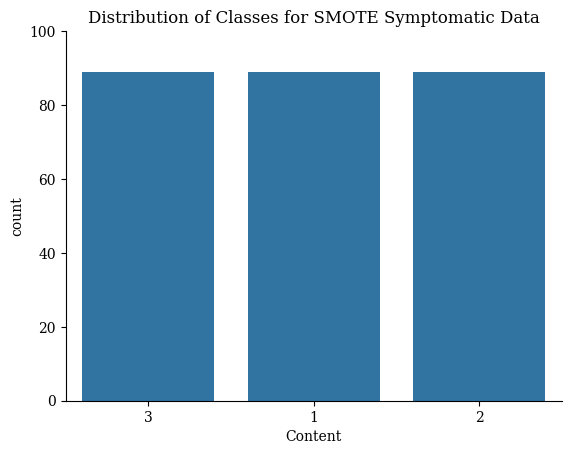

In [ ]:
sns.countplot(x=y_balanced.map({0: '1', 1: '2', 2: '3'}))
plt.title('Distribution of Classes for SMOTE Symptomatic Data')
plt.ylim(0, 100)
for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
      if spine.spine_type != 'bottom' and spine.spine_type != 'left':
        spine.set_visible(False)
plt.show()

##Creating new dataframe of smote balanced symptomatic original data size.

In [ ]:
sym_smote = pd.DataFrame(x_balanced)

In [ ]:
x_balanced

,Gender_male,Gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,1,0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.000000,2.000000,2.000000,2.000000
1,1,0,2,2,2,3,3,2,2,3,...,2,1,2,2,3,1,2.330000,1.670000,1.830000,1.940000
2,1,0,1,2,2,2,2,2,2,2,...,2,2,2,2,2,2,1.830000,2.000000,2.000000,1.940000
3,1,0,2,3,2,2,2,2,2,2,...,3,2,3,3,2,2,2.170000,2.170000,2.500000,2.280000
4,1,0,1,2,2,0,0,0,3,3,...,0,0,2,3,4,4,0.830000,2.170000,2.170000,1.720000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,0,0,1,2,2,2,2,2,2,2,...,2,2,2,2,2,2,1.830000,2.000000,2.000000,1.940000
263,0,1,1,1,2,2,2,2,1,3,...,2,2,2,2,2,1,1.830000,2.073526,2.256474,2.060000
264,0,1,1,0,1,0,2,2,1,3,...,3,1,2,3,2,0,1.430266,2.302828,2.130133,1.957038
265,0,0,1,1,2,2,1,2,2,2,...,2,1,2,2,2,2,1.739514,2.000000,2.046614,1.926290


In [ ]:
sym_smote

,Gender_male,Gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_1,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score
0,1,0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2.000000,2.000000,2.000000,2.000000
1,1,0,2,2,2,3,3,2,2,3,...,2,1,2,2,3,1,2.330000,1.670000,1.830000,1.940000
2,1,0,1,2,2,2,2,2,2,2,...,2,2,2,2,2,2,1.830000,2.000000,2.000000,1.940000
3,1,0,2,3,2,2,2,2,2,2,...,3,2,3,3,2,2,2.170000,2.170000,2.500000,2.280000
4,1,0,1,2,2,0,0,0,3,3,...,0,0,2,3,4,4,0.830000,2.170000,2.170000,1.720000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,0,0,1,2,2,2,2,2,2,2,...,2,2,2,2,2,2,1.830000,2.000000,2.000000,1.940000
263,0,1,1,1,2,2,2,2,1,3,...,2,2,2,2,2,1,1.830000,2.073526,2.256474,2.060000
264,0,1,1,0,1,0,2,2,1,3,...,3,1,2,3,2,0,1.430266,2.302828,2.130133,1.957038
265,0,0,1,1,2,2,1,2,2,2,...,2,1,2,2,2,2,1.739514,2.000000,2.046614,1.926290


In [ ]:
target2 = y_balanced.to_frame(name='Target')

In [ ]:
print(target2.value_counts())

Target
0         89
1         89
2         89
Name: count, dtype: int64


In [ ]:
sym_smote = sym_smote.merge(target2, left_index=True, right_index=True)

In [ ]:
sym_smote

,Gender_male,Gender_female,AT_1,AT_2,AT_3,AT_4,AT_5,AT_6,HA_1,HA_2,...,IM_2,IM_3,IM_4,IM_5,IM_6,1_6 Score,7_12 Score,13_18 Score,1_18 score,Target
0,1,0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2.000000,2.000000,2.000000,2.000000,2
1,1,0,2,2,2,3,3,2,2,3,...,1,2,2,3,1,2.330000,1.670000,1.830000,1.940000,0
2,1,0,1,2,2,2,2,2,2,2,...,2,2,2,2,2,1.830000,2.000000,2.000000,1.940000,1
3,1,0,2,3,2,2,2,2,2,2,...,2,3,3,2,2,2.170000,2.170000,2.500000,2.280000,2
4,1,0,1,2,2,0,0,0,3,3,...,0,2,3,4,4,0.830000,2.170000,2.170000,1.720000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,0,0,1,2,2,2,2,2,2,2,...,2,2,2,2,2,1.830000,2.000000,2.000000,1.940000,1
263,0,1,1,1,2,2,2,2,1,3,...,2,2,2,2,1,1.830000,2.073526,2.256474,2.060000,1
264,0,1,1,0,1,0,2,2,1,3,...,1,2,3,2,0,1.430266,2.302828,2.130133,1.957038,1
265,0,0,1,1,2,2,1,2,2,2,...,1,2,2,2,2,1.739514,2.000000,2.046614,1.926290,1


##Creating csv file of smote balanced data

In [ ]:
#sym_smote.to_csv("Balanced_symdata.csv", index=False)

In [ ]:
x_smote2 = sym_smote.drop(columns=['Target'])
y_smote2 = sym_smote['Target']

In [ ]:
MinMaxScaler = preprocessing.MinMaxScaler()
RobustScaler = preprocessing.RobustScaler()
minmax_x_smote2 = MinMaxScaler.fit_transform(x_smote2)
robust_x_smote2 = RobustScaler.fit_transform(x_smote2)
#minmax scaler is better with k nearest neighbour
#robust scaler works well for balanced classes, however it turns some numbers into negatives which can't be used with naive bayes
minmax_x_smote2

array([[1.        , 0.        , 0.5       , ..., 0.33333333, 0.45504087,
        0.2       ],
       [1.        , 0.        , 0.5       , ..., 0.22333333, 0.40871935,
        0.176     ],
       [1.        , 0.        , 0.25      , ..., 0.33333333, 0.45504087,
        0.176     ],
       ...,
       [0.        , 1.        , 0.25      , ..., 0.43427614, 0.49049952,
        0.18281534],
       [0.        , 0.        , 0.25      , ..., 0.33333333, 0.4677423 ,
        0.17051597],
       [0.        , 0.        , 0.25      , ..., 0.41009985, 0.46903565,
        0.20345566]])

In [ ]:
x_trainsmo, x_testsmo, y_trainsmo, y_testsmo = train_test_split(minmax_x_smote2, y_smote2, test_size=0.2, random_state=42)


In [ ]:
knn_clf.fit(x_trainsmo, y_trainsmo)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
#x_trainnb2, x_testnb2, y_trainnb2, y_testnb2 = train_test_split(x_smote, y_smote, test_size=0.2, random_state=42)

In [ ]:
nbclassifier.fit(x_trainsmo, y_trainsmo)

GaussianNB()

In [ ]:
ypred_knn_smo = knn_clf.predict(x_testsmo)
ypred_nb_smo = nbclassifier.predict(x_testsmo)

In [ ]:
print("\nSymptomatic Balanced K-Nearest Neighbour Classification Report:")
print(classification_report(y_testsmo, ypred_knn_smo))
print("Confusion Matrix:") # should show all 3 classes
print(confusion_matrix(y_testsmo, ypred_knn_smo))


Symptomatic Balanced K-Nearest Neighbour Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       0.86      1.00      0.92        18
           2       1.00      0.78      0.88        18

    accuracy                           0.93        54
   macro avg       0.93      0.93      0.92        54
weighted avg       0.93      0.93      0.92        54

Confusion Matrix:
[[18  0  0]
 [ 0 18  0]
 [ 1  3 14]]



Symptomatic Balanced K-Nearest Neighbour Confusion Matrix:


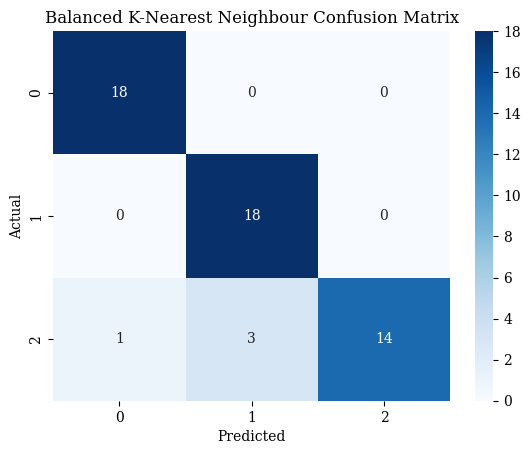

In [ ]:
print("\nSymptomatic Balanced K-Nearest Neighbour Confusion Matrix:")
conf_matrix = confusion_matrix(y_testsmo, ypred_knn_smo)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Balanced K-Nearest Neighbour Confusion Matrix')
plt.show()

Minmax scaler has the same macro average as robust scaler however, minmax scaler has a better model performance for each class than robust scaler which is overfitting and has a okay class 2.

In [ ]:
print("\nSymptomatic Balanced Naive Bayes Classification Report:")
print(classification_report(y_testsmo, ypred_nb_smo))
print("Confusion Matrix:")  # should show all 3 classes
print(confusion_matrix(y_testsmo, ypred_nb_smo))


Symptomatic Balanced Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.90      1.00      0.95        18
           2       1.00      0.89      0.94        18

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54

Confusion Matrix:
[[18  0  0]
 [ 0 18  0]
 [ 0  2 16]]


True positives are in the diagonal of the confusion matrix.

Class 0 and 1 are overfitting with 100% recall. Class 2 is 89% recall.


Symptomatic Balanced Naive Bayes Confusion Matrix:


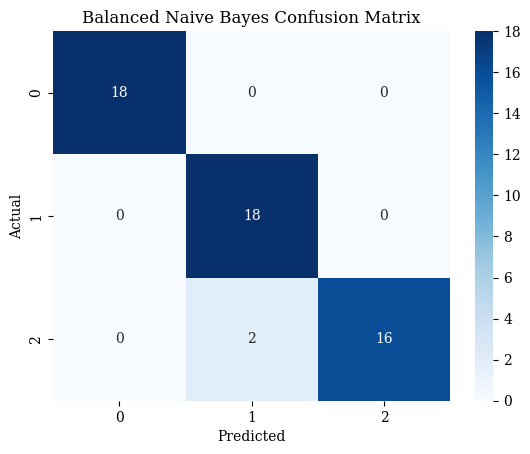

In [ ]:
print("\nSymptomatic Balanced Naive Bayes Confusion Matrix:")
conf_matrix = confusion_matrix(y_testsmo, ypred_nb_smo)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Balanced Naive Bayes Confusion Matrix')
plt.show()

#ROC Curve with balanced symptomatic results

In [ ]:
from sklearn.metrics import roc_curve, auc, recall_score
from sklearn.preprocessing import label_binarize

KNN - Class with highest recall: 0
KNN - Class with lowest recall: 2


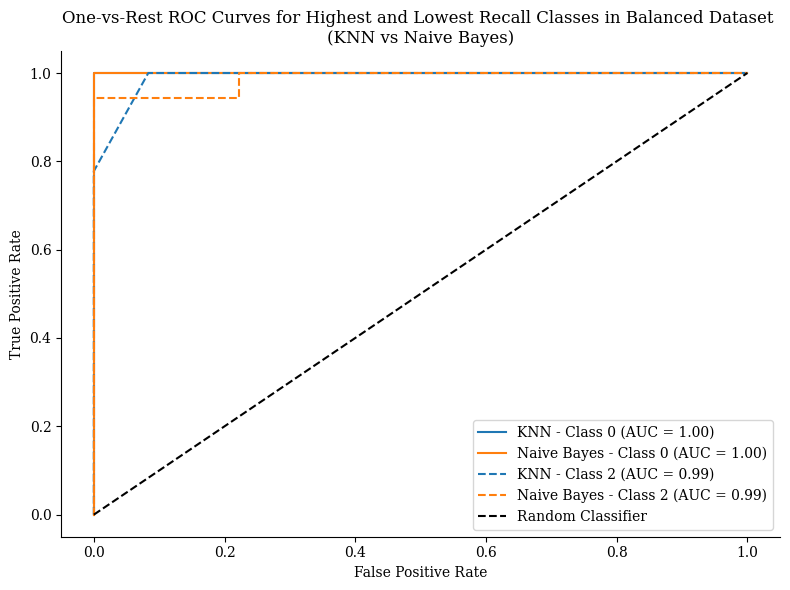

In [ ]:
y_score_knn = knn_clf.predict_proba(x_testsmo)

# Compute recall and pick highest + lowest recall classes
recalls = recall_score(y_testsmo, ypred_knn_smo, average=None)
classes = np.unique(y_testsmo)
highest_cls = classes[np.argmax(recalls)]
lowest_cls = classes[np.argmin(recalls)]

print(f"KNN - Class with highest recall: {highest_cls}")
print(f"KNN - Class with lowest recall: {lowest_cls}")

# Binarize test labels
y_test_bin = label_binarize(y_testsmo, classes=classes)


y_score_nb = nbclassifier.predict_proba(x_testsmo)
# Binarize NB test labels (same class ordering)
y_testnb_bin = label_binarize(y_testsmo, classes=classes)

# Colors for each classifier
plt.figure(figsize=(8, 6))

# Fixed color map by classifier
color_map = {
    'KNN': '#1f77b4',       # Default blue
    'NB': '#ff7f0e'         # Default orange
}

# Class-specific linestyles
linestyle_map = {
    highest_cls: '-',       # Solid for highest recall class
    lowest_cls: '--'        # Dashed for lowest recall class
}

# Plot both models for highest and lowest recall classes
for cls in [highest_cls, lowest_cls]:
    linestyle = linestyle_map[cls]

    # KNN
    fpr_knn, tpr_knn, _ = roc_curve(y_test_bin[:, cls], y_score_knn[:, cls])
    auc_knn = auc(fpr_knn, tpr_knn)
    plt.plot(fpr_knn, tpr_knn, color=color_map['KNN'], linestyle=linestyle,
             label=f'KNN - Class {cls} (AUC = {auc_knn:.2f})')

    # Naive Bayes
    fpr_nb, tpr_nb, _ = roc_curve(y_testnb_bin[:, cls], y_score_nb[:, cls])
    auc_nb = auc(fpr_nb, tpr_nb)
    plt.plot(fpr_nb, tpr_nb, color=color_map['NB'], linestyle=linestyle,
             label=f'Naive Bayes - Class {cls} (AUC = {auc_nb:.2f})')

# random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
#random classifier is the base classifier of which others are compared

# Final touches
plt.title('One-vs-Rest ROC Curves for Highest and Lowest Recall Classes in Balanced Dataset \n(KNN vs Naive Bayes)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
      if spine.spine_type != 'bottom' and spine.spine_type != 'left':
        spine.set_visible(False)
plt.show()